# Overview (Candidate)
* Separate male/female from the dataset
* Add medication to the male/female dataset
* Impute NaNs

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import pickle
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import utilities as u
import plot
import custom_impute as ci

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    # "Sk-Learn": sys.modules['sklearn'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    2.3.1
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/CAN_Heart_Data.pkl")
# display
df.head()

,PreviousTransplantNumber_CAN,WaitListDiagnosisCode_CAN,Gender_CAN,BloodGroup_CAN,Citizenship_CAN,ResidencyStateRegistration_CAN,EducationLevel_CAN,LifeSupportRegistration_ECMO_CAN,LifeSupportRegistration_IABP_CAN,LifeSupportInhaled_CAN,InotropesIVRegistration_CAN,LifeSupportRegistration_PGE_CAN,LifeSupportMechanismRegistration_OTHER_CAN,VentricularDeviceTypeRegistration_CAN,VentricularDeviceBrandRegistration_CAN,FunctionalStatusRegistration_CAN,PrimaryPaymentRegistration_CAN,DiagnosisAtListing_CAN,DiabetesType_CAN,DialysisTypeRegistration_CAN,CerebroVascularDisease_CAN,PreviousMalignancy_CAN,CreatinineRegistration_CAN,DefibrillatorImplantRegistration_CAN,HemodynamicsRegistration_SYS_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_CO_CAN,InotropesVasodilatorsRegistration_SYS_CAN,InotropesVasodilatorsRegistration_DIA_CAN,InotropesVasodilatorsRegistration_MN_CAN,InotropesVasodilatorsRegistration_PCW_CAN,InotropesVasodilatorsRegistration_CO_CAN,CigaretteUse_CAN,CigaretteAbstinence_CAN,PriorCardiacSurgery_CAN,PriorCardiacSurgeryType_CAN,ReceivedDeceasedDonorTramsplant_CAN,TotalDayWaitList_CAN,StatusAtTransplant_CAN,Age_Listing_CAN,LifeSupportRegistration_CAN,Ethnicity_CAN,HeightCm_CAN,WeightKg_CAN,VentilatorRegistration_CAN,TransplantRegion_CAN,WorkIncomeRegistration_CAN,AntigenBW4_CAN,AntigenBW6_CAN,AntigenC1_CAN,AntigenC2_CAN,AntigenDR51_CAN,AntigenDR51_2_CAN,AntigenDR52_CAN,AntigenDR52_2_CAN,AntigenDR53_CAN,AntigenDR53_2_CAN,AntigenDQ1_CAN,AntigenDQ2_CAN,FunctionalStatusTransplant_CAN,MedicalConditionTransplant_CAN,PrimaryPaymentTransplant_CAN,LifeSupportTransplant_ECMO_CAN,ResidencyStateTransplant_CAN,WorkIncomeTransplant_CAN,LifeSupportTransplant_PGE_CAN,CreatinineTransplant_CAN,DialysisBetweenRegistrationTransplant_CAN,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN,LifeSupportTransplant_IABP_CAN,InfectionTherapyIV_CAN,InotropesIVTransplant_CAN,InotropesVasodilatorsTransplant_CO_CAN,InotropesVasodilatorsTransplant_DIA_CAN,InotropesVasodilatorsTransplant_MN_CAN,InotropesVasodilatorsTransplant_PCW_CAN,InotropesVasodilatorsTransplant_SYS_CAN,LifeSupportMechanismTransplant_OTHER_CAN,PriorLungSurgeryAfterRegistration_CAN,SteroidsUse_CAN,TotalBilirubinTransplant_CAN,TransfusionAfterRegistration_CAN,VentricularDeviceTypeTransplant_CAN,VentricularDeviceBrandTransplant_CAN,VentilatorySupport_CAN,VentilatorTransplant_CAN,LifeSupportInhaledTransplant_CAN,PriorCardiacSurgeryTypeListAndTransplant_CAN,Hepatitis_B_CoreAntibody_CAN,SurfaceAntigenHEP_B_CAN,SurfaceHBVAntibodyTotalTransplant_CAN,CMVStatus_Transplant_CAN,HIV_SeroStatusTransplant_CAN,HEP_C_SerostatusStatus_CAN,EpsteinBarrSeroStatusTransplant_CAN,HIV_NAT_PreTransplant_CAN,HCV_NAT_PreTranspant_CAN,HBV_NAT_Result_CAN,LifeSupportInhaledRegistration_CAN,PreviousTransplantSameOrgan_CAN,PreviousTransplantAnyOrgan_CAN,AntigenRA1_CAN,AntigenRA2_CAN,AntigenRB1_CAN,AntigenRB2_CAN,AntigenRDR1_CAN,AntigenRDR2_CAN,MalignancyBetweenRegistrationTransplant_CAN,CMV_IGG_Transplant_CAN,CMV_IGM_Transplant_CAN,TransplantType_CAN,Age_CAN,PrimaryDiagnosisType_CAN,DialysisPriorRegistration_CAN,LifeSupportTransplant_CAN,PriorCardiacSurgeryListAndTransplant_CAN,Malignancy_CAN,DistanceFromHospitaltoTXCenter_CAN,VentilatorySupportAfterRegistration_CAN,HeartProcedureType_CAN,TransplantYear_CAN,ListingYear_CAN,TransplantSurvivalDay
0,0,DILATED MYOPATHY: IDIOPATHIC,M,A,US Citizen,CA,ATTENDED COLLEGE/TECHNICAL SCHOOL,No,No,No,No,No,Yes,Lvad+Rvad,CentriMag (Thoratec/Levitronix),0.1,Public insurance - Medicaid,DILATED MYOPATHY: IDIOPATHIC,No,No dialysis,No,No,1.3,Yes,50.0,34.0,37.0,36.0,2.50,Yes,Yes,Yes,Yes,Yes,No,Missing,Yes,Valve Replace/Repair,Yes,11,Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,45,Yes,Hispanic,172.7,65.8,No,Region 5,No,0,0,0,0,0,0,0,0,0,0,0,0,0.1,

In [3]:
df.info(max_cols=df.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 28326 entries, 0 to 28750
Data columns (total 129 columns):
 #    Column                                        Non-Null Count  Dtype   
---   ------                                        --------------  -----   
 0    PreviousTransplantNumber_CAN                  28326 non-null  category
 1    WaitListDiagnosisCode_CAN                     28326 non-null  category
 2    Gender_CAN                                    28326 non-null  category
 3    BloodGroup_CAN                                28326 non-null  category
 4    Citizenship_CAN                               28326 non-null  category
 5    ResidencyStateRegistration_CAN                28326 non-null  category
 6    EducationLevel_CAN                            28326 non-null  category
 7    LifeSupportRegistration_ECMO_CAN              28326 non-null  category
 8    LifeSupportRegistration_IABP_CAN              28326 non-null  category
 9    LifeSupportInhaled_CAN                    

## Gender

In [4]:
u.any_nans(df)

--- Missing Values Found () (Total Rows: 28,326) ---
                                     Count Percentage
HemodynamicsRegistration_PCW_CAN      2642    9.3271%
HemodynamicsTransplant_PCW_CAN        2050    7.2372%
HemodynamicsRegistration_CO_CAN       1588    5.6062%
FunctionalStatusTransplant_CAN        1352    4.7730%
HemodynamicsRegistration_PA_MN_CAN    1264    4.4623%
HemodynamicsTransplant_CO_CAN         1240    4.3776%
HemodynamicsTransplant_PA_MN_CAN      1064    3.7563%
HemodynamicsRegistration_PA_DIA_CAN    997    3.5197%
HemodynamicsRegistration_SYS_CAN       976    3.4456%
FunctionalStatusRegistration_CAN       952    3.3609%
HemodynamicsTransplant_PA_DIA_CAN      802    2.8313%
HemodynamicsTransplant_SYS_CAN         782    2.7607%
TotalBilirubinTransplant_CAN            96    0.3389%
CreatinineRegistration_CAN              95    0.3354%
CreatinineTransplant_CAN                55    0.1942%
WeightKg_CAN                             7    0.0247%


In [5]:
df.Gender_CAN.value_counts(dropna=False)

Gender_CAN
M    20737
F     7589
Name: count, dtype: int64

In [6]:
df_m = df[df.Gender_CAN == 'M'].copy()
df_f = df[df.Gender_CAN == 'F'].copy()
#
df_m.shape, df_f.shape

((20737, 129), (7589, 129))

### User Function(s)

In [7]:
def plot_histogram(data, column, bins=30, txt='', title_font=20, tick_font=10, KDE=True):
    """
    Plotting histograms of multiple columns in a single figure. 
    """
    plt.figure(figsize=(10, 6))  # width, height in inches
    # plot
    ax = sns.histplot(
        data=data,
        x=column,
        kde=KDE,
        bins=bins
    )
    # aesthetics
    plt.title(f"{txt}", fontsize=title_font)
    plt.ylabel("Frequency", fontsize=tick_font, fontweight='bold')
    plt.xlabel(column, fontsize=tick_font, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Hemodynamics Registration

#### Male

In [8]:
# info
features = u.get_feature_info(df_m, 'HemodynamicsRegistration', cat=False)

                                       count       mean        std   min   25%   50%   75%    max
HemodynamicsRegistration_CO_CAN      19590.0   4.426968   1.350360  0.39   3.5   4.3   5.2   15.0
HemodynamicsRegistration_PA_DIA_CAN  20056.0  20.843448   8.781906  0.00  15.0  20.0  27.0   83.0
HemodynamicsRegistration_PA_MN_CAN   19831.0  29.059915  10.312086  0.00  21.0  29.0  36.0   87.0
HemodynamicsRegistration_PCW_CAN     18801.0  19.533855   8.894973  0.00  13.0  19.0  25.0   50.0
HemodynamicsRegistration_SYS_CAN     20073.0  42.636626  14.453643  0.00  32.0  42.0  52.0  123.0

:::: NaN Count:
HemodynamicsRegistration_CO_CAN        1147
HemodynamicsRegistration_PA_DIA_CAN     681
HemodynamicsRegistration_PA_MN_CAN      906
HemodynamicsRegistration_PCW_CAN       1936
HemodynamicsRegistration_SYS_CAN        664 



Those hemodynamic variables (Cardiac Output, Pulmonary Artery pressures, and Wedge pressure) are notorious for having missing data in donor registries because they require invasive Swan-Ganz catheterization, which isn't performed on every donor.

* CO (Cardiac Output)
* PA_DIA (Pulmonary Artery Diastolic)
* PA_MN (Pulmonary Artery Mean)
* PCW (Pulmonary Capillary Wedge)
* SYS (Systemic Arterial Systolic)

In [9]:
df_m[features].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.235612,-0.213548,-0.259455,-0.176352
HemodynamicsRegistration_PA_DIA_CAN,-0.235612,1.000000,0.895528,0.822832,0.783811
HemodynamicsRegistration_PA_MN_CAN,-0.213548,0.895528,1.000000,0.839889,0.920671
HemodynamicsRegistration_PCW_CAN,-0.259455,0.822832,0.839889,1.000000,0.764891
HemodynamicsRegistration_SYS_CAN,-0.176352,0.783811,0.920671,0.764891,1.000000


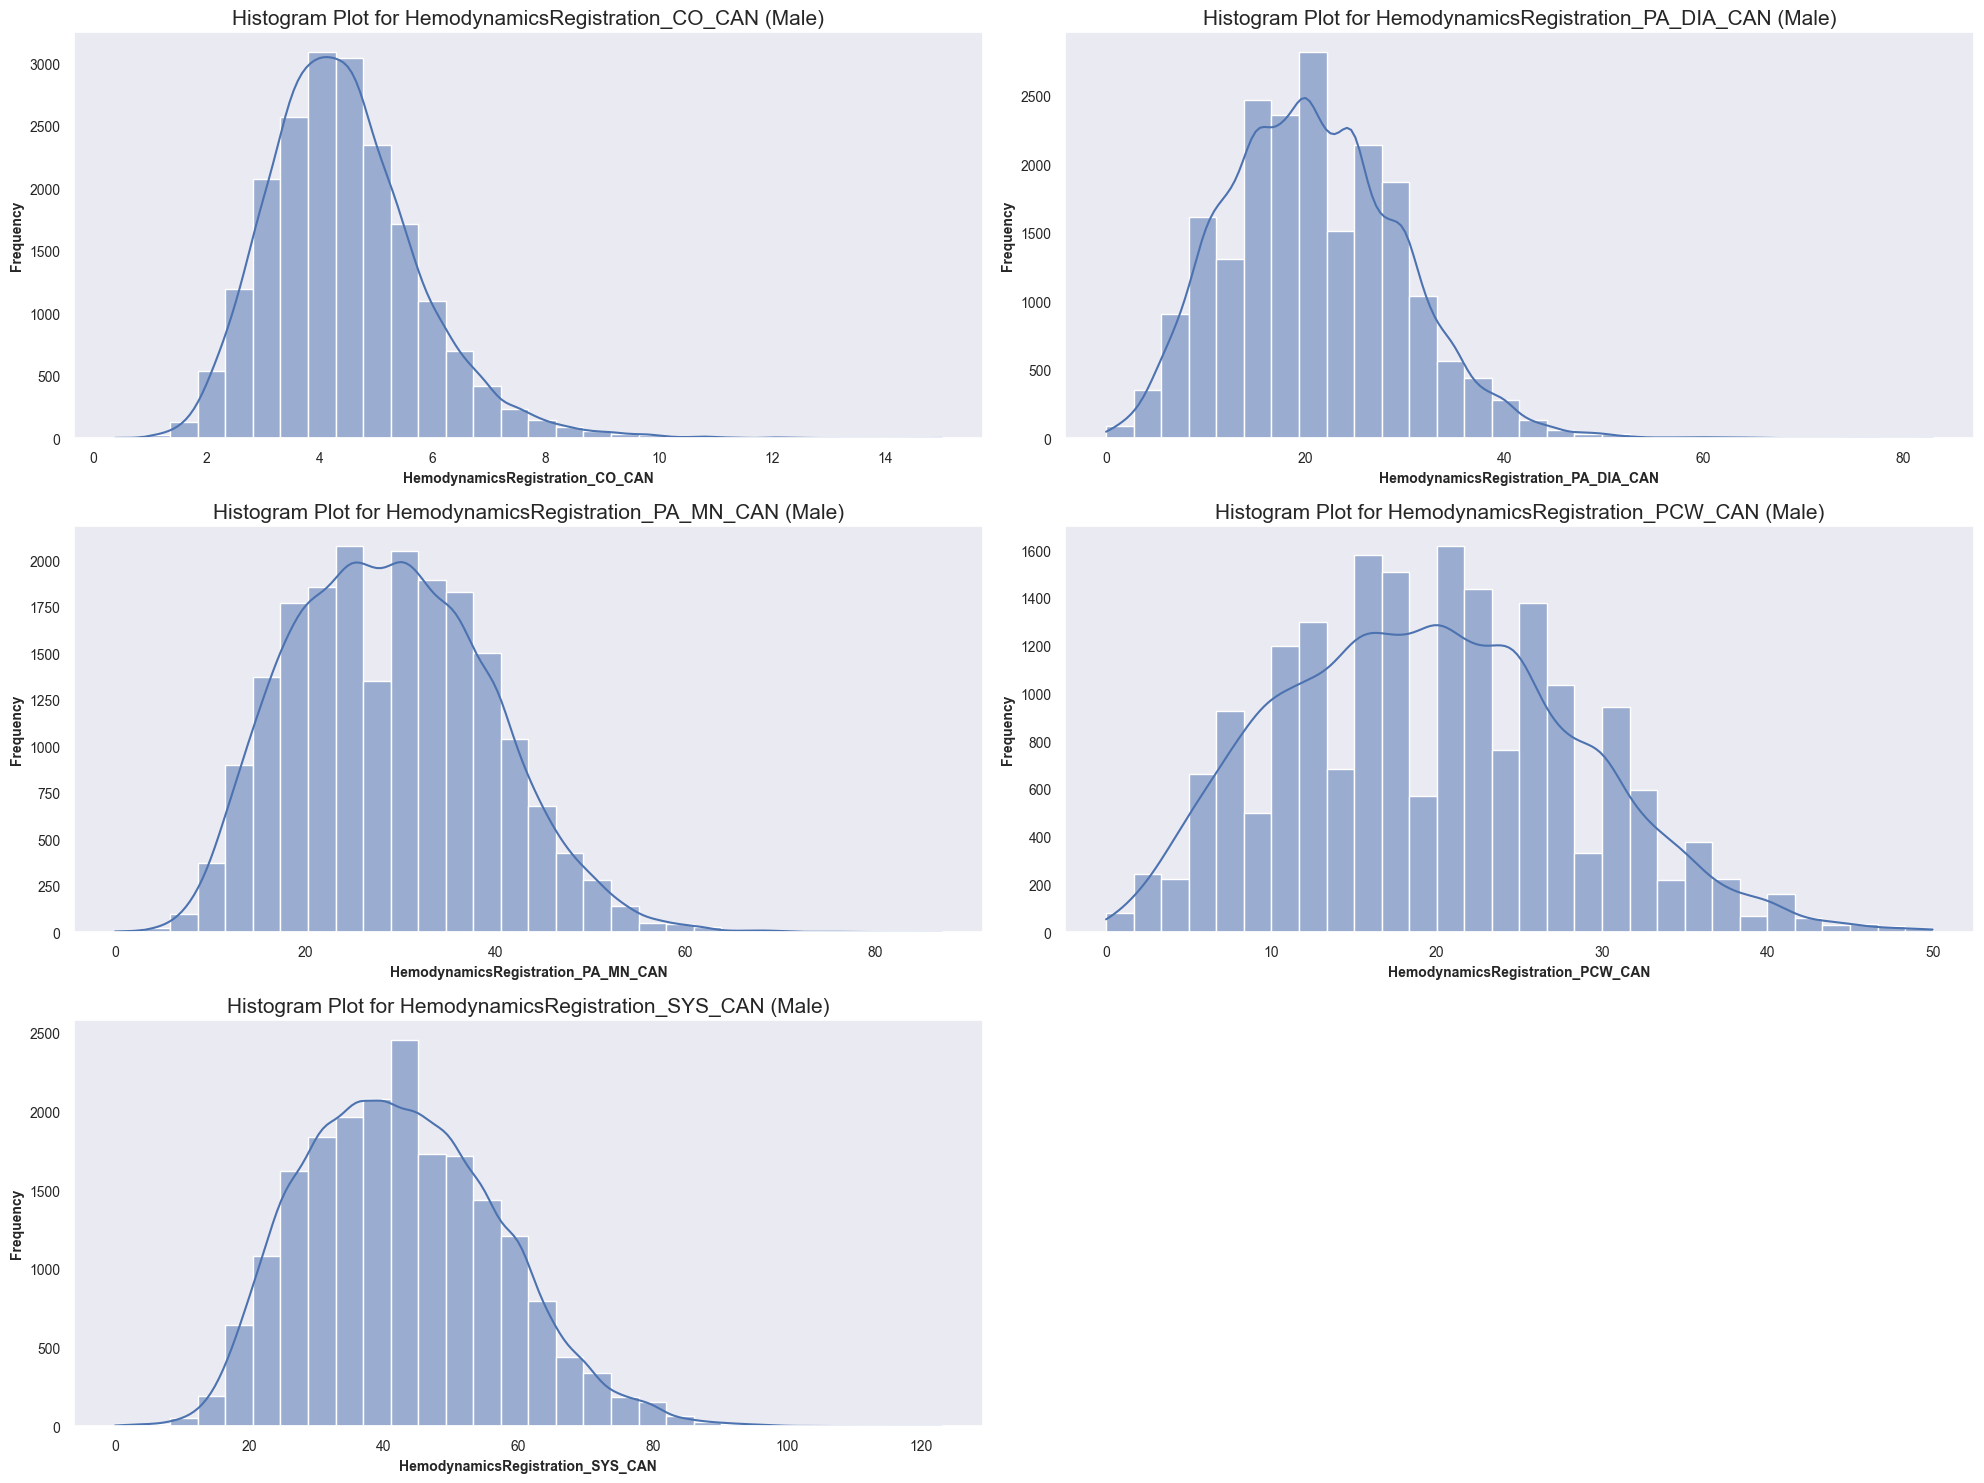

In [10]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male)')

In [11]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_CO_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_CO_CAN ---
Group Sizes:    (Unknown=1,147, Known=19,590)
Mean survival:  (Unknown=1,287.9d, Known=1,331.9d)
Difference:     -44.1 days

--- Welch's t-test Analysis ---
ρ-Value: 0.1953
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0415 (Negligible)
95% CI:        [-0.1010, 0.0181]
Result: Likely Random Missingness (Effect size not significant)



In [12]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_CO_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_CO_CAN ---
Pearson r=-0.001, p=0.8591 & Approx. Variance Explained=0.000%
Spearman r=0.001, p=0.8631 & Approx. Variance Explained=0.000%



#### Median Imputation

In [13]:
# Median impute
df_m['HemodynamicsRegistration_CO_CAN'] = df_m['HemodynamicsRegistration_CO_CAN'].fillna(
    df_m['HemodynamicsRegistration_CO_CAN'].median()
)

In [14]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_PA_DIA_CAN ---
Group Sizes:    (Unknown=681, Known=20,056)
Mean survival:  (Unknown=1,219.0d, Known=1,333.3d)
Difference:     -114.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0100
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1076 (Negligible)
95% CI:        [-0.1840, -0.0312]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



#### The "Shadow Variable" (Indicator) + Median Imputation

In [15]:
# impute: median and use new feature for NANS
df_m['HemodynamicsRegistration_PA_DIA_Ismissing'] = df_m['HemodynamicsRegistration_PA_DIA_CAN'].isna().astype(int)
df_m['HemodynamicsRegistration_PA_DIA_CAN'] = df_m['HemodynamicsRegistration_PA_DIA_CAN'].fillna(
    df_m['HemodynamicsRegistration_PA_DIA_CAN'].median()
)

In [16]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_PA_DIA_CAN ---
Pearson r=0.026, p=0.0001581 & Approx. Variance Explained=0.069%
Spearman r=0.024, p=0.0006538 & Approx. Variance Explained=0.056%



In [17]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PA_MN_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_PA_MN_CAN ---
Group Sizes:    (Unknown=906, Known=19,831)
Mean survival:  (Unknown=1,357.7d, Known=1,328.2d)
Difference:     29.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.4556
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0278 (Negligible)
95% CI:        [-0.0388, 0.0944]
Result: Likely Random Missingness (Effect size not significant)



In [18]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PA_MN_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_PA_MN_CAN ---
Pearson r=0.035, p=6.787e-07 & Approx. Variance Explained=0.124%
Spearman r=0.032, p=5.721e-06 & Approx. Variance Explained=0.104%



#### Median Imputation

In [19]:
# Median impute
df_m['HemodynamicsRegistration_PA_MN_CAN'] = df_m['HemodynamicsRegistration_PA_MN_CAN'].fillna(
    df_m['HemodynamicsRegistration_PA_MN_CAN'].median()
)

In [20]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PCW_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_PCW_CAN ---
Group Sizes:    (Unknown=1,936, Known=18,801)
Mean survival:  (Unknown=1,330.9d, Known=1,329.4d)
Difference:     1.6 days

--- Welch's t-test Analysis ---
ρ-Value: 0.9523
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0015 (Negligible)
95% CI:        [-0.0453, 0.0482]
Result: Likely Random Missingness (Effect size not significant)



In [21]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PCW_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_PCW_CAN ---
Pearson r=0.036, p=5.977e-07 & Approx. Variance Explained=0.132%
Spearman r=0.033, p=6.236e-06 & Approx. Variance Explained=0.109%



#### Median Imputation

In [22]:
# Median impute
df_m['HemodynamicsRegistration_PCW_CAN'] = df_m['HemodynamicsRegistration_PCW_CAN'].fillna(
    df_m['HemodynamicsRegistration_PCW_CAN'].median()
)

In [23]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_SYS_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_SYS_CAN ---
Group Sizes:    (Unknown=664, Known=20,073)
Mean survival:  (Unknown=1,216.1d, Known=1,333.3d)
Difference:     -117.1 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0091
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1103 (Negligible)
95% CI:        [-0.1876, -0.0330]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [24]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_SYS_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_SYS_CAN ---
Pearson r=0.038, p=4.9e-08 & Approx. Variance Explained=0.148%
Spearman r=0.036, p=4.238e-07 & Approx. Variance Explained=0.127%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [25]:
# impute: median and use new feature for NANS
df_m['HemodynamicsRegistration_SYS_Ismissing'] = df_m['HemodynamicsRegistration_SYS_CAN'].isna().astype(int)
df_m['HemodynamicsRegistration_SYS_CAN'] = df_m['HemodynamicsRegistration_SYS_CAN'].fillna(
    df_m['HemodynamicsRegistration_SYS_CAN'].median()
)

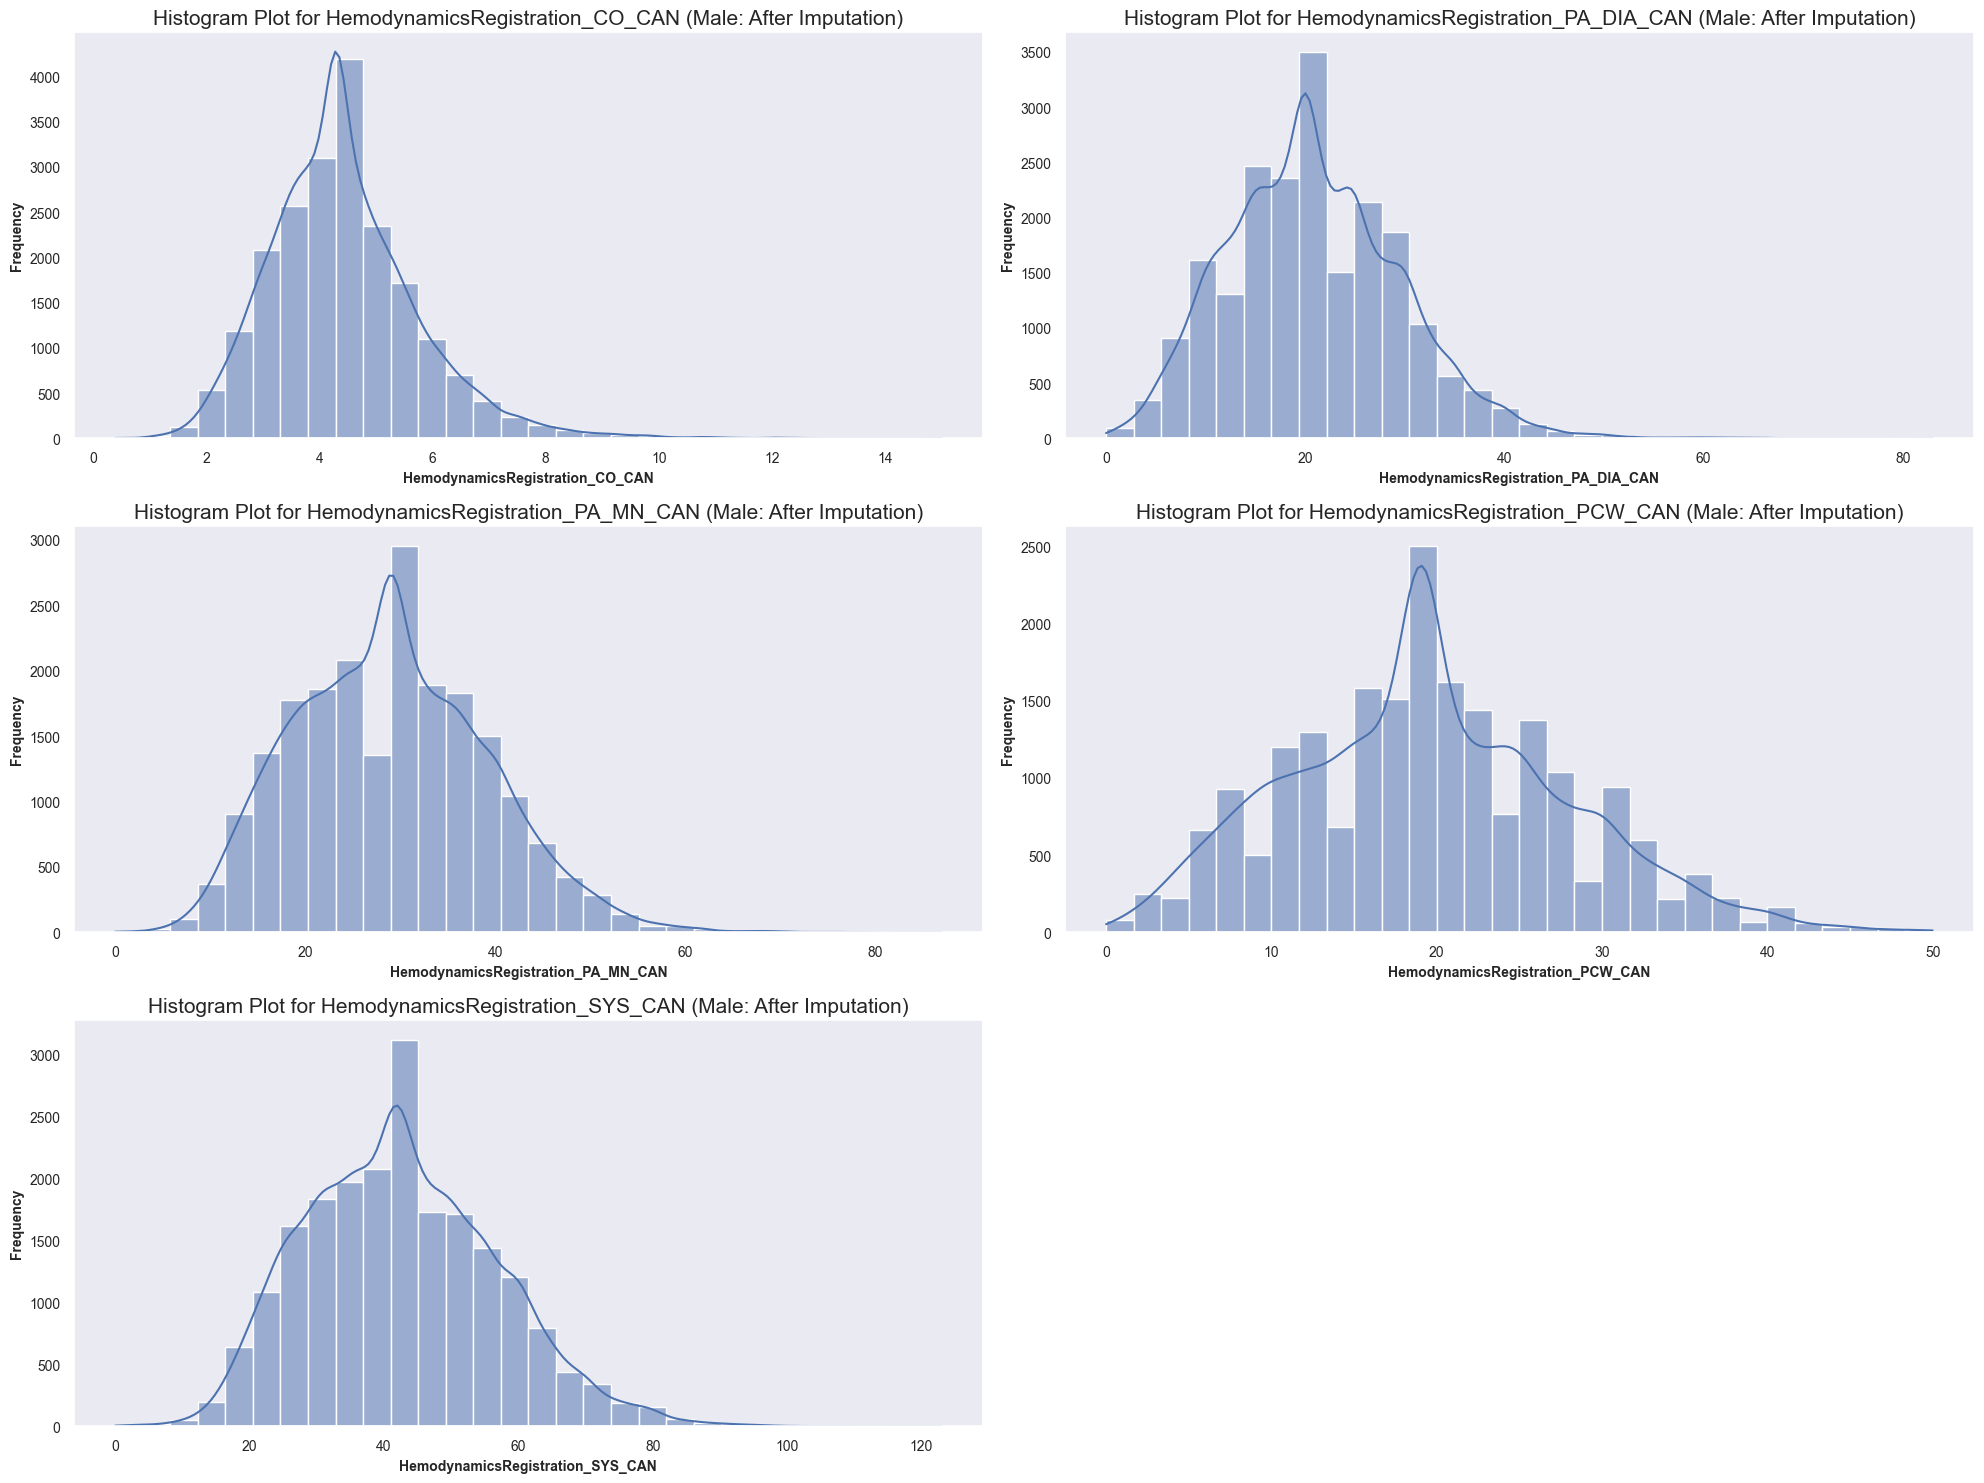

In [26]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male: After Imputation)')

#### **Note:** Use PCA for hemodynamic variables since there are some features that are highly correlated.

In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# scale for PCA
X_scaled = StandardScaler().fit_transform(df_m[features].values)

# PCA
pca = PCA(n_components=0.9, random_state=SEED).fit(X_scaled)  # 90% variance
print(f"Components: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Add to dataframe
pca_scores = pca.transform(X_scaled)
for i in range(pca.n_components_):
    df_m[f'PC{i+1}_hemo_registration'] = pca_scores[:, i]

# drop columns
df_m = df_m.drop(columns=features)
# shape
df_m.shape

Components: 3
Explained variance: [0.706923   0.18666591 0.05527068]


(20737, 129)

#### Female

In [28]:
# info
features = u.get_feature_info(df_f, 'HemodynamicsRegistration', cat=False)

                                      count       mean        std   min      25%    50%   75%    max
HemodynamicsRegistration_CO_CAN      7148.0   3.822310   1.222956  0.91   2.9875   3.69   4.5   15.0
HemodynamicsRegistration_PA_DIA_CAN  7273.0  19.717311   8.370123  0.00  14.0000  19.00  25.0   91.0
HemodynamicsRegistration_PA_MN_CAN   7231.0  27.628244   9.838857  4.00  20.0000  27.00  34.0   96.0
HemodynamicsRegistration_PCW_CAN     6883.0  18.111652   8.433316  0.00  12.0000  18.00  24.0   50.0
HemodynamicsRegistration_SYS_CAN     7277.0  40.551326  13.553369  0.00  31.0000  40.00  50.0  130.0

:::: NaN Count:
HemodynamicsRegistration_CO_CAN        441
HemodynamicsRegistration_PA_DIA_CAN    316
HemodynamicsRegistration_PA_MN_CAN     358
HemodynamicsRegistration_PCW_CAN       706
HemodynamicsRegistration_SYS_CAN       312 



In [29]:
df_f[features].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.205351,-0.178502,-0.235942,-0.129223
HemodynamicsRegistration_PA_DIA_CAN,-0.205351,1.000000,0.883735,0.823780,0.788469
HemodynamicsRegistration_PA_MN_CAN,-0.178502,0.883735,1.000000,0.828155,0.909364
HemodynamicsRegistration_PCW_CAN,-0.235942,0.823780,0.828155,1.000000,0.752129
HemodynamicsRegistration_SYS_CAN,-0.129223,0.788469,0.909364,0.752129,1.000000


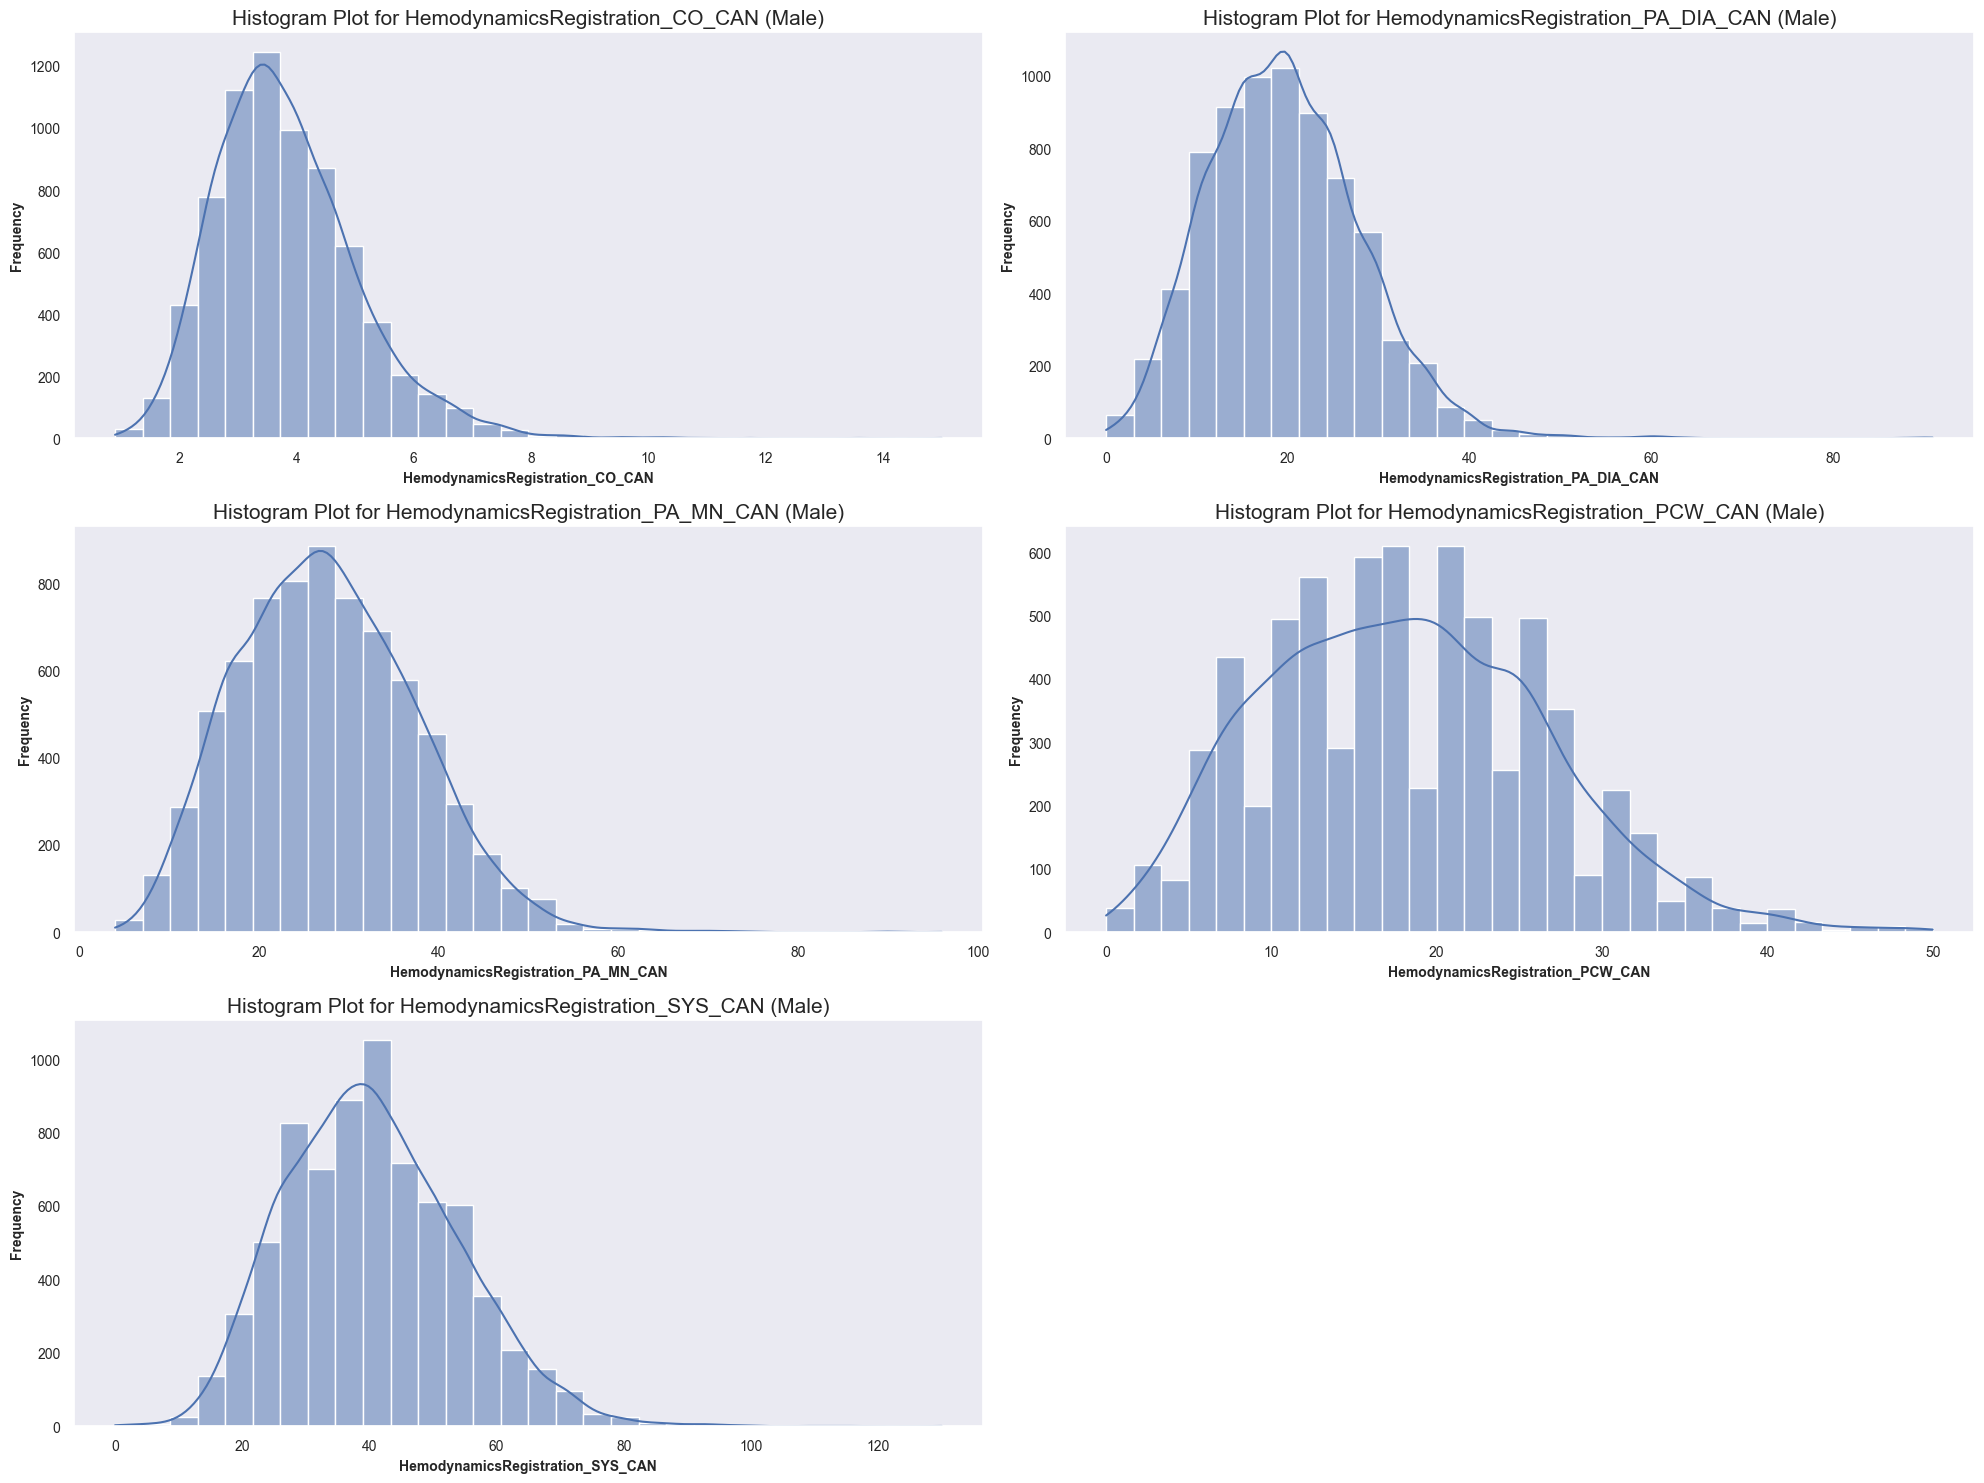

In [30]:
plot.plot_histogram(df_f, features, bins=30, txt='(Male)')

In [31]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_CO_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_CO_CAN ---
Group Sizes:    (Unknown=441, Known=7,148)
Mean survival:  (Unknown=1,349.6d, Known=1,330.7d)
Difference:     18.9 days

--- Welch's t-test Analysis ---
ρ-Value: 0.7300
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0177 (Negligible)
95% CI:        [-0.0785, 0.1139]
Result: Likely Random Missingness (Effect size not significant)



In [32]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsRegistration_CO_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsRegistration_CO_CAN ---
Pearson r=-0.022, p=0.06854 & Approx. Variance Explained=0.046%
Spearman r=-0.019, p=0.1087 & Approx. Variance Explained=0.036%



#### Median Imputation

In [33]:
# Median impute
df_f['HemodynamicsRegistration_CO_CAN'] = df_f['HemodynamicsRegistration_CO_CAN'].fillna(
    df_f['HemodynamicsRegistration_CO_CAN'].median()
)

In [34]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_PA_DIA_CAN ---
Group Sizes:    (Unknown=316, Known=7,273)
Mean survival:  (Unknown=1,296.1d, Known=1,333.4d)
Difference:     -37.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.5670
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0349 (Negligible)
95% CI:        [-0.1475, 0.0777]
Result: Likely Random Missingness (Effect size not significant)



In [35]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsRegistration_PA_DIA_CAN ---
Pearson r=0.042, p=0.0003465 & Approx. Variance Explained=0.176%
Spearman r=0.041, p=0.0004923 & Approx. Variance Explained=0.167%



#### Median Imputation

In [36]:
# Median impute
df_f['HemodynamicsRegistration_PA_DIA_CAN'] = df_f['HemodynamicsRegistration_PA_DIA_CAN'].fillna(
    df_f['HemodynamicsRegistration_PA_DIA_CAN'].median()
)

In [37]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PA_MN_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_PA_MN_CAN ---
Group Sizes:    (Unknown=358, Known=7,231)
Mean survival:  (Unknown=1,425.5d, Known=1,327.2d)
Difference:     98.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.1260
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0920 (Negligible)
95% CI:        [-0.0141, 0.1982]
Result: Likely Random Missingness (Effect size not significant)



#### Median Imputation

In [38]:
# Median impute
df_f['HemodynamicsRegistration_PA_MN_CAN'] = df_f['HemodynamicsRegistration_PA_MN_CAN'].fillna(
    df_f['HemodynamicsRegistration_PA_MN_CAN'].median()
)

In [39]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PCW_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_PCW_CAN ---
Group Sizes:    (Unknown=706, Known=6,883)
Mean survival:  (Unknown=1,371.3d, Known=1,327.7d)
Difference:     43.6 days

--- Welch's t-test Analysis ---
ρ-Value: 0.3236
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0408 (Negligible)
95% CI:        [-0.0367, 0.1183]
Result: Likely Random Missingness (Effect size not significant)



#### Median Imputation

In [40]:
# Median impute
df_f['HemodynamicsRegistration_PCW_CAN'] = df_f['HemodynamicsRegistration_PCW_CAN'].fillna(
    df_f['HemodynamicsRegistration_PCW_CAN'].median()
)

In [41]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_SYS_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_SYS_CAN ---
Group Sizes:    (Unknown=312, Known=7,277)
Mean survival:  (Unknown=1,293.8d, Known=1,333.4d)
Difference:     -39.7 days

--- Welch's t-test Analysis ---
ρ-Value: 0.5421
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0371 (Negligible)
95% CI:        [-0.1504, 0.0762]
Result: Likely Random Missingness (Effect size not significant)



#### Median Imputation

In [42]:
# Median impute
df_f['HemodynamicsRegistration_SYS_CAN'] = df_f['HemodynamicsRegistration_SYS_CAN'].fillna(
    df_f['HemodynamicsRegistration_SYS_CAN'].median()
)

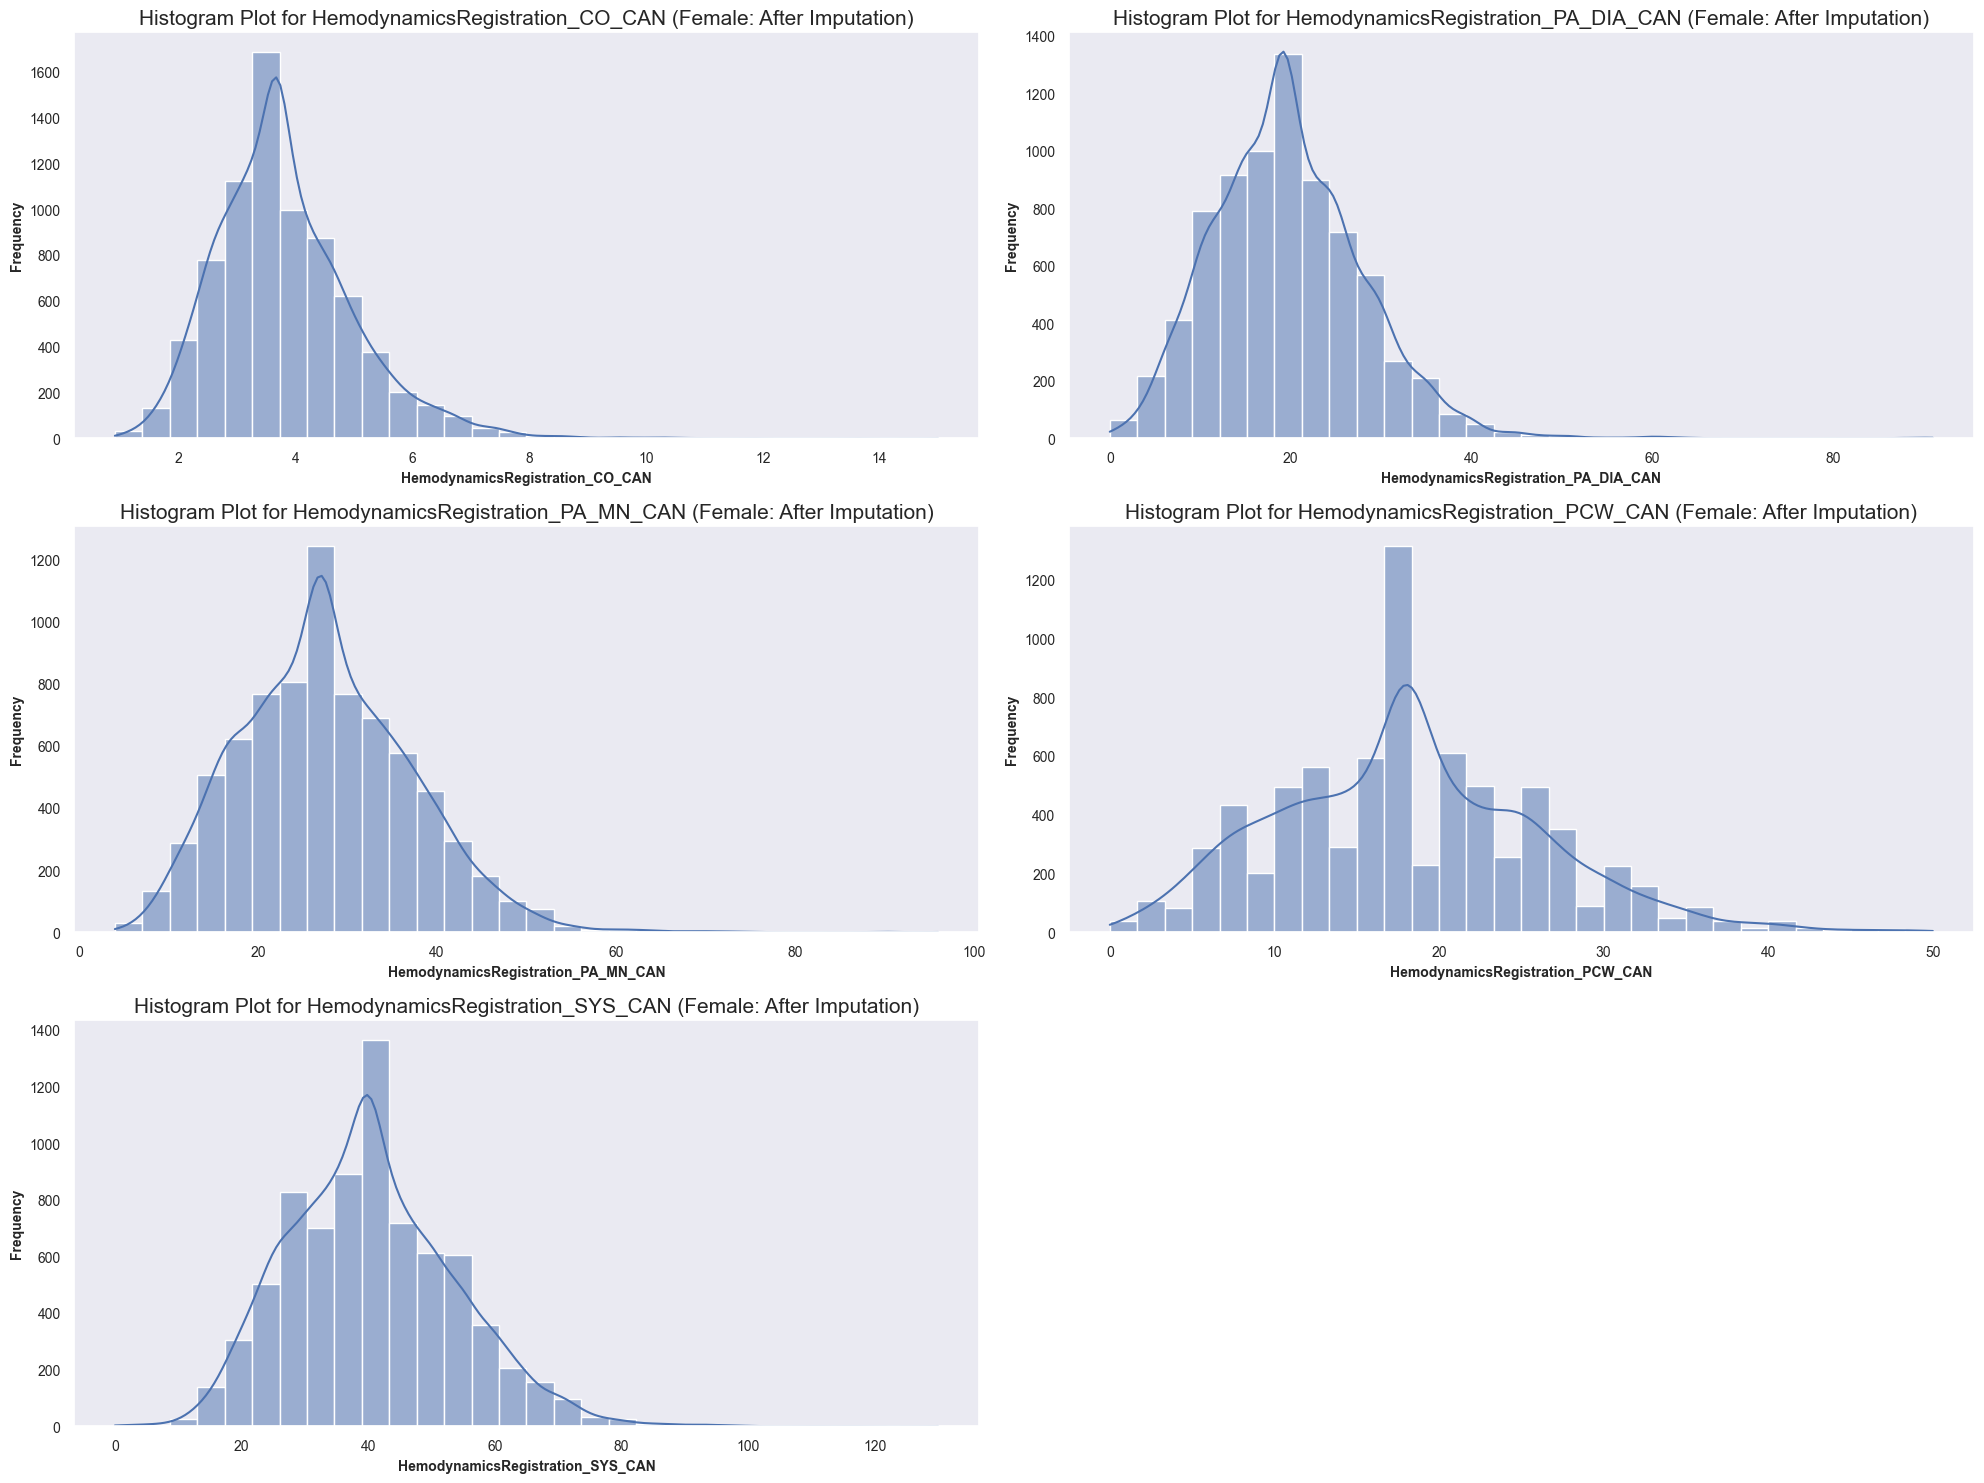

In [43]:
plot.plot_histogram(df_f, features, bins=30, txt='(Female: After Imputation)')

In [44]:
# scale for PCA
X_scaled = StandardScaler().fit_transform(df_f[features].values)

# PCA
pca = PCA(n_components=0.9, random_state=SEED).fit(X_scaled)  # 90% variance
print(f"Components: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Add to dataframe
pca_scores = pca.transform(X_scaled)
for i in range(pca.n_components_):
    df_f[f'PC{i+1}_hemo_registration'] = pca_scores[:, i]

# drop columns
df_f = df_f.drop(columns=features)
# shape
df_f.shape

Components: 3
Explained variance: [0.69717465 0.19133644 0.05738098]


(7589, 127)

## Hemodynamics Transplant

#### Male

In [45]:
# info
features = u.get_feature_info(df_m, 'HemodynamicsTransplant', cat=False)

                                     count       mean        std  min   25%    50%   75%    max
HemodynamicsTransplant_CO_CAN      19868.0   4.715230   1.465477  0.2   3.7   4.55   5.5   15.0
HemodynamicsTransplant_PA_DIA_CAN  20192.0  19.339402   8.562328  0.0  13.0  18.00  25.0  110.0
HemodynamicsTransplant_PA_MN_CAN   19989.0  27.233478  10.006183  0.0  20.0  26.00  34.0  110.0
HemodynamicsTransplant_PCW_CAN     19246.0  18.035215   8.756555  0.0  11.0  17.00  24.0   50.0
HemodynamicsTransplant_SYS_CAN     20207.0  40.092641  13.984482  1.0  30.0  38.00  49.0  159.0

:::: NaN Count:
HemodynamicsTransplant_CO_CAN         869
HemodynamicsTransplant_PA_DIA_CAN     545
HemodynamicsTransplant_PA_MN_CAN      748
HemodynamicsTransplant_PCW_CAN       1491
HemodynamicsTransplant_SYS_CAN        530 



In [46]:
df_m[features].corr()

,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN
HemodynamicsTransplant_CO_CAN,1.000000,-0.237909,-0.206392,-0.239612,-0.177014
HemodynamicsTransplant_PA_DIA_CAN,-0.237909,1.000000,0.904482,0.822103,0.794961
HemodynamicsTransplant_PA_MN_CAN,-0.206392,0.904482,1.000000,0.834541,0.918454
HemodynamicsTransplant_PCW_CAN,-0.239612,0.822103,0.834541,1.000000,0.764728
HemodynamicsTransplant_SYS_CAN,-0.177014,0.794961,0.918454,0.764728,1.000000


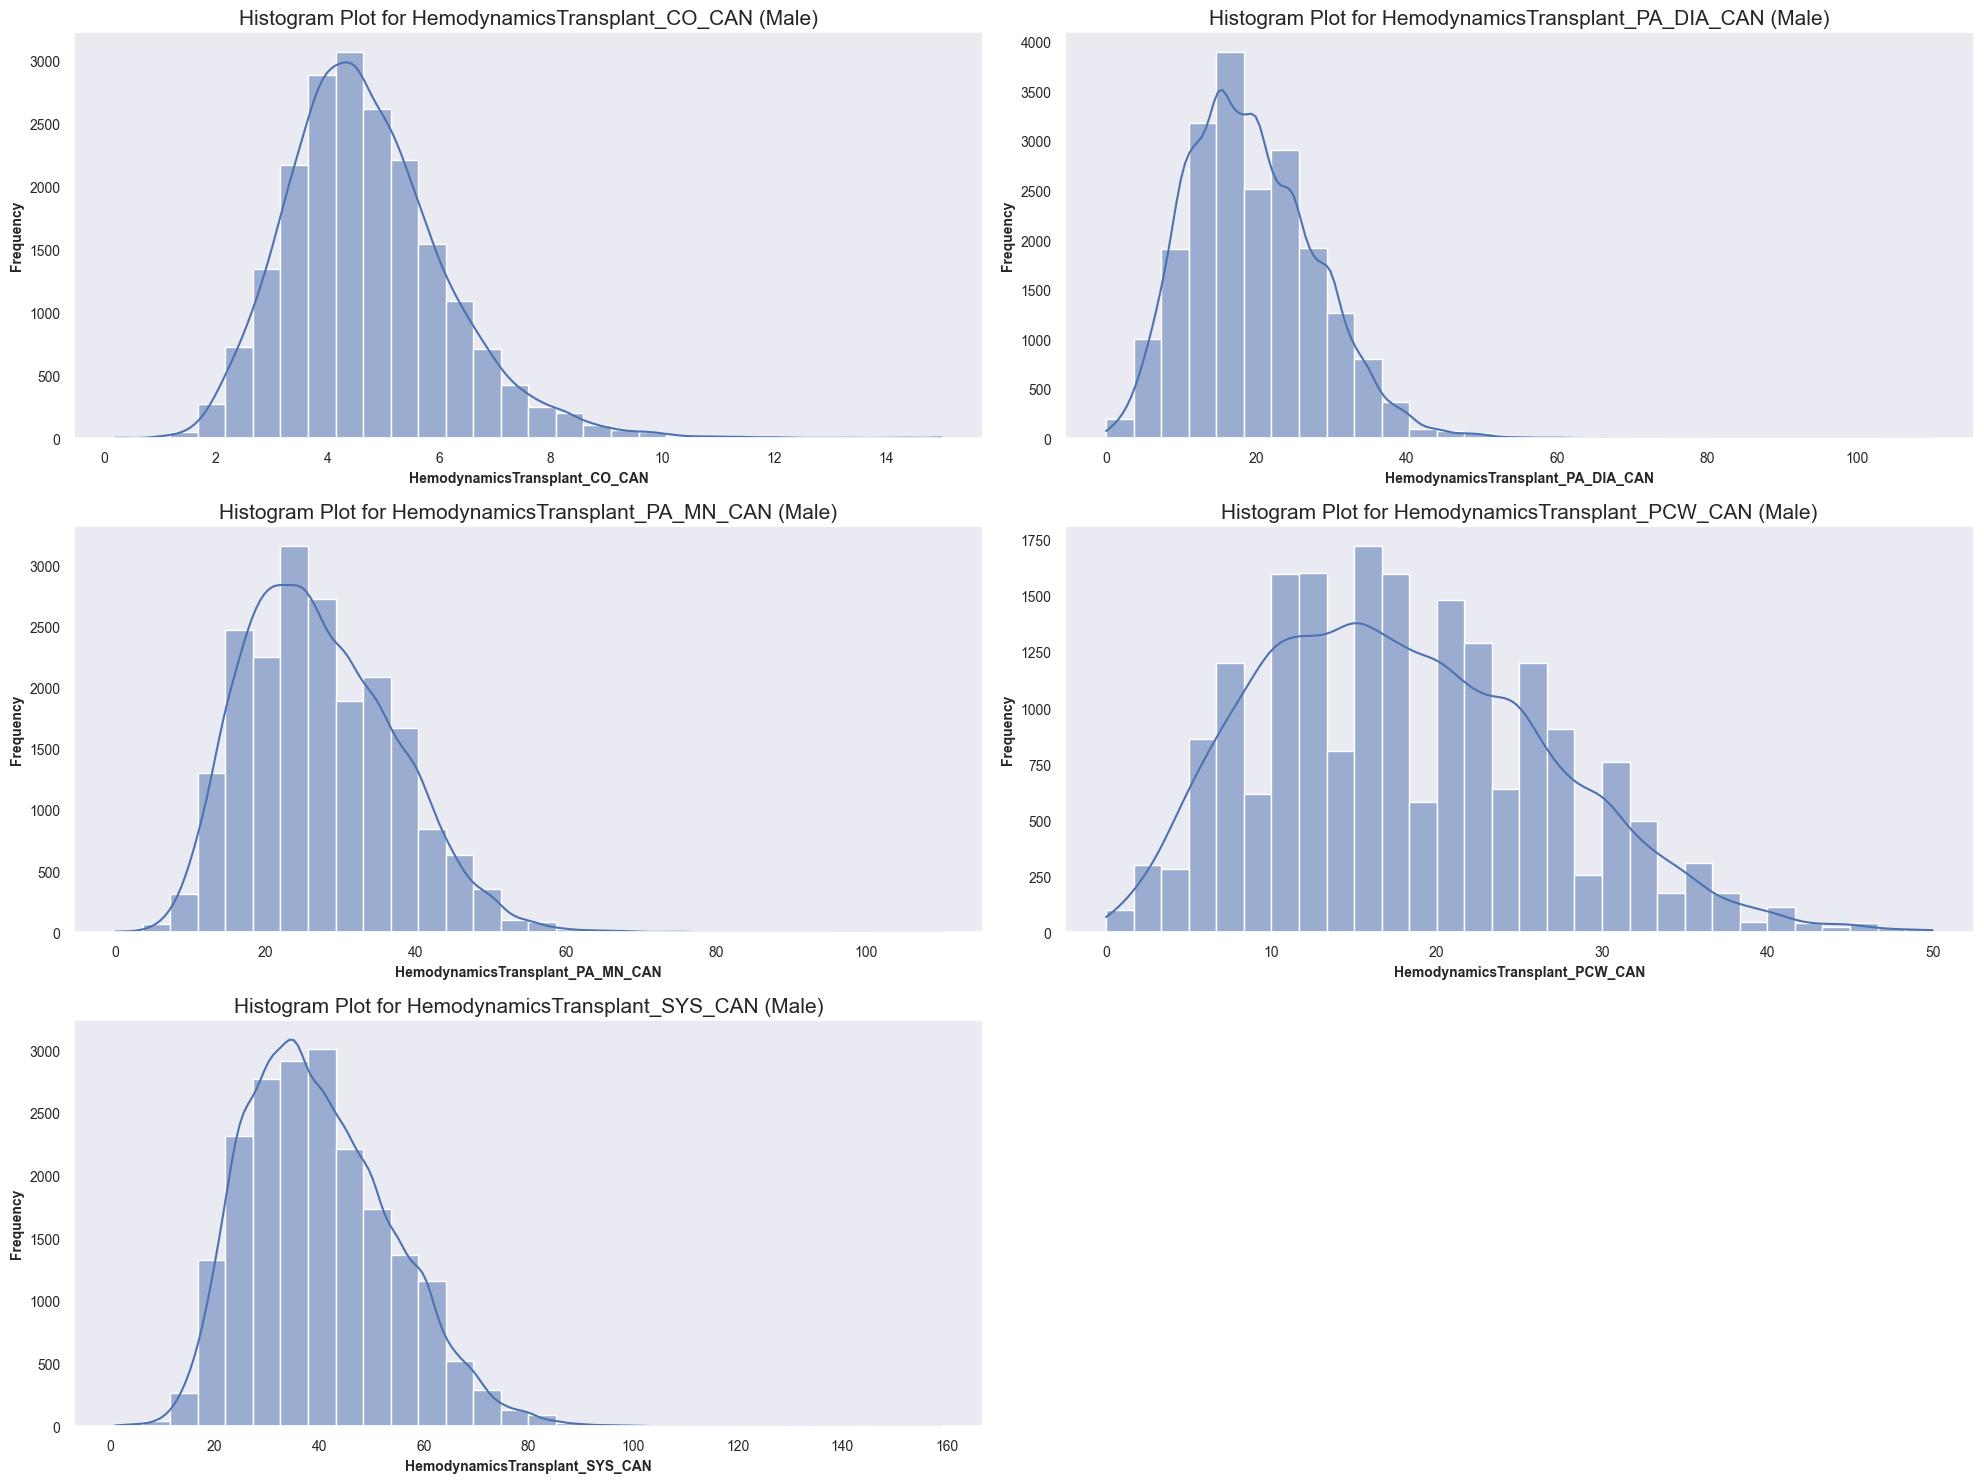

In [47]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male)')

In [48]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_CO_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_CO_CAN ---
Group Sizes:    (Unknown=869, Known=19,868)
Mean survival:  (Unknown=1,096.3d, Known=1,339.7d)
Difference:     -243.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2294 (Small)
95% CI:        [-0.2974, -0.1615]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [49]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_CO_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_CO_CAN ---
Pearson r=0.018, p=0.01106 & Approx. Variance Explained=0.032%
Spearman r=0.028, p=8.965e-05 & Approx. Variance Explained=0.077%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [50]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_CO_Ismissing'] = df_m['HemodynamicsTransplant_CO_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_CO_CAN'] = df_m['HemodynamicsTransplant_CO_CAN'].fillna(
    df_m['HemodynamicsTransplant_CO_CAN'].median()
)

In [51]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_PA_DIA_CAN ---
Group Sizes:    (Unknown=545, Known=20,192)
Mean survival:  (Unknown=1,035.9d, Known=1,337.4d)
Difference:     -301.6 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2843 (Small)
95% CI:        [-0.3694, -0.1991]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [52]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_PA_DIA_CAN ---
Pearson r=-0.023, p=0.001322 & Approx. Variance Explained=0.051%
Spearman r=-0.026, p=0.0001837 & Approx. Variance Explained=0.069%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [53]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PA_DIA_Ismissing'] = df_m['HemodynamicsTransplant_PA_DIA_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PA_DIA_CAN'] = df_m['HemodynamicsTransplant_PA_DIA_CAN'].fillna(
    df_m['HemodynamicsTransplant_PA_DIA_CAN'].median()
)

In [54]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PA_MN_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_PA_MN_CAN ---
Group Sizes:    (Unknown=748, Known=19,989)
Mean survival:  (Unknown=1,163.2d, Known=1,335.7d)
Difference:     -172.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1625 (Negligible)
95% CI:        [-0.2355, -0.0895]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [55]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PA_MN_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_PA_MN_CAN ---
Pearson r=-0.010, p=0.1609 & Approx. Variance Explained=0.010%
Spearman r=-0.015, p=0.03085 & Approx. Variance Explained=0.023%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [56]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PA_MN_Ismissing'] = df_m['HemodynamicsTransplant_PA_MN_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PA_MN_CAN'] = df_m['HemodynamicsTransplant_PA_MN_CAN'].fillna(
    df_m['HemodynamicsTransplant_PA_MN_CAN'].median()
)

In [57]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PCW_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_PCW_CAN ---
Group Sizes:    (Unknown=1,491, Known=19,246)
Mean survival:  (Unknown=1,154.3d, Known=1,343.1d)
Difference:     -188.8 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1780 (Negligible)
95% CI:        [-0.2307, -0.1253]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [58]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PCW_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_PCW_CAN ---
Pearson r=-0.007, p=0.3513 & Approx. Variance Explained=0.005%
Spearman r=-0.013, p=0.06841 & Approx. Variance Explained=0.017%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [59]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PCW_Ismissing'] = df_m['HemodynamicsTransplant_PCW_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PCW_CAN'] = df_m['HemodynamicsTransplant_PCW_CAN'].fillna(
    df_m['HemodynamicsTransplant_PCW_CAN'].median()
)

In [60]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_SYS_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_SYS_CAN ---
Group Sizes:    (Unknown=530, Known=20,207)
Mean survival:  (Unknown=1,018.8d, Known=1,337.7d)
Difference:     -318.8 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.3005 (Small)
95% CI:        [-0.3868, -0.2142]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [61]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_SYS_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_SYS_CAN ---
Pearson r=-0.003, p=0.6652 & Approx. Variance Explained=0.001%
Spearman r=-0.011, p=0.1106 & Approx. Variance Explained=0.013%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [62]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_SYS_Ismissing'] = df_m['HemodynamicsTransplant_SYS_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_SYS_CAN'] = df_m['HemodynamicsTransplant_SYS_CAN'].fillna(
    df_m['HemodynamicsTransplant_SYS_CAN'].median()
)

#### Female

In [63]:
# info
features = u.get_feature_info(df_f, 'HemodynamicsTransplant', cat=False)

                                    count       mean        std  min    25%   50%   75%    max
HemodynamicsTransplant_CO_CAN      7218.0   4.051886   1.319523  0.2   3.13   3.9   4.8   15.0
HemodynamicsTransplant_PA_DIA_CAN  7332.0  18.608702   8.208180  0.0  13.00  18.0  24.0   65.0
HemodynamicsTransplant_PA_MN_CAN   7273.0  26.384200   9.656789  0.0  19.00  25.0  33.0   88.0
HemodynamicsTransplant_PCW_CAN     7030.0  17.022397   8.400556  0.0  10.00  16.0  23.0   50.0
HemodynamicsTransplant_SYS_CAN     7337.0  38.752051  13.291202  0.0  29.00  37.0  47.0  127.0

:::: NaN Count:
HemodynamicsTransplant_CO_CAN        371
HemodynamicsTransplant_PA_DIA_CAN    257
HemodynamicsTransplant_PA_MN_CAN     316
HemodynamicsTransplant_PCW_CAN       559
HemodynamicsTransplant_SYS_CAN       252 



In [64]:
df_f[features].corr()

,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN
HemodynamicsTransplant_CO_CAN,1.000000,-0.207517,-0.173649,-0.228658,-0.140496
HemodynamicsTransplant_PA_DIA_CAN,-0.207517,1.000000,0.891131,0.812089,0.779296
HemodynamicsTransplant_PA_MN_CAN,-0.173649,0.891131,1.000000,0.825614,0.912886
HemodynamicsTransplant_PCW_CAN,-0.228658,0.812089,0.825614,1.000000,0.748660
HemodynamicsTransplant_SYS_CAN,-0.140496,0.779296,0.912886,0.748660,1.000000


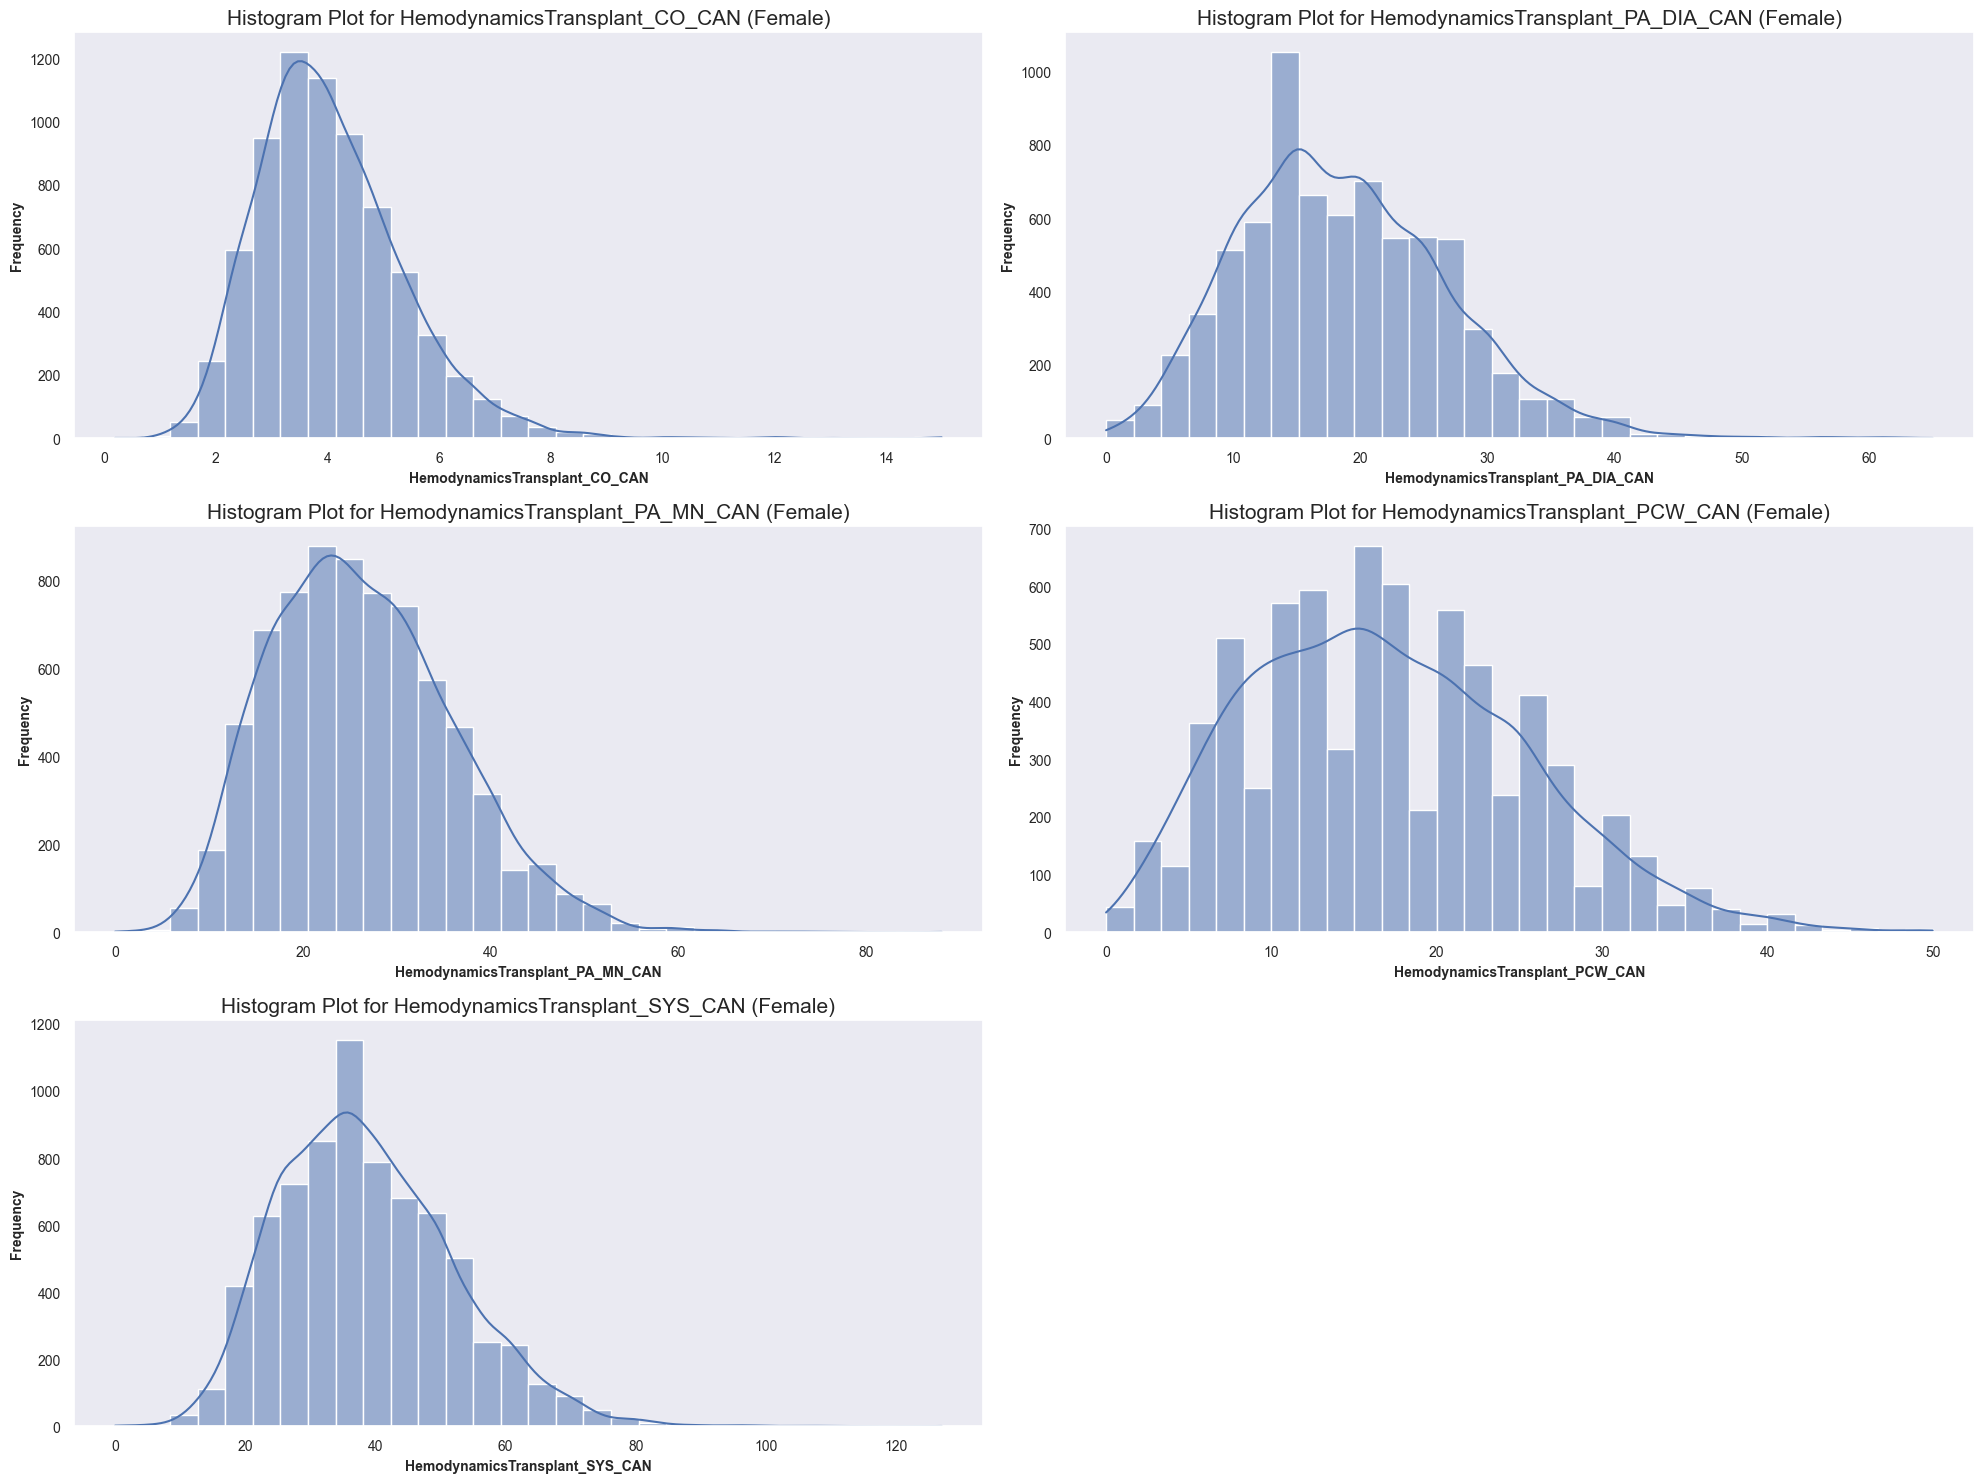

In [65]:
plot.plot_histogram(df_f, features, bins=30, txt='(Female)')

In [66]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_CO_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_CO_CAN ---
Group Sizes:    (Unknown=371, Known=7,218)
Mean survival:  (Unknown=1,272.0d, Known=1,334.9d)
Difference:     -62.8 days

--- Welch's t-test Analysis ---
ρ-Value: 0.3054
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0588 (Negligible)
95% CI:        [-0.1631, 0.0455]
Result: Likely Random Missingness (Effect size not significant)



In [67]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_CO_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_CO_CAN ---
Pearson r=-0.023, p=0.04912 & Approx. Variance Explained=0.054%
Spearman r=-0.015, p=0.1996 & Approx. Variance Explained=0.023%



#### Median Imputation

In [68]:
# Median impute
df_f['HemodynamicsTransplant_CO_CAN'] = df_f['HemodynamicsTransplant_CO_CAN'].fillna(
    df_f['HemodynamicsTransplant_CO_CAN'].median()
)

In [69]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_PA_DIA_CAN ---
Group Sizes:    (Unknown=257, Known=7,332)
Mean survival:  (Unknown=1,213.8d, Known=1,335.9d)
Difference:     -122.1 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0950
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.1143 (Negligible)
95% CI:        [-0.2387, 0.0101]
Result: Likely Random Missingness (Effect size not significant)



In [70]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_PA_DIA_CAN ---
Pearson r=0.012, p=0.3219 & Approx. Variance Explained=0.013%
Spearman r=-0.001, p=0.9252 & Approx. Variance Explained=0.000%



#### Median Imputation

In [71]:
# Median impute
df_f['HemodynamicsTransplant_PA_DIA_CAN'] = df_f['HemodynamicsTransplant_PA_DIA_CAN'].fillna(
    df_f['HemodynamicsTransplant_PA_DIA_CAN'].median()
)

In [72]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PA_MN_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_PA_MN_CAN ---
Group Sizes:    (Unknown=316, Known=7,273)
Mean survival:  (Unknown=1,241.3d, Known=1,335.7d)
Difference:     -94.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.1536
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0884 (Negligible)
95% CI:        [-0.2010, 0.0242]
Result: Likely Random Missingness (Effect size not significant)



In [73]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PA_MN_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_PA_MN_CAN ---
Pearson r=0.023, p=0.04741 & Approx. Variance Explained=0.054%
Spearman r=0.009, p=0.442 & Approx. Variance Explained=0.008%



#### Median Imputation

In [74]:
# Median impute
df_f['HemodynamicsTransplant_PA_MN_CAN'] = df_f['HemodynamicsTransplant_PA_MN_CAN'].fillna(
    df_f['HemodynamicsTransplant_PA_MN_CAN'].median()
)

In [75]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PCW_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_PCW_CAN ---
Group Sizes:    (Unknown=559, Known=7,030)
Mean survival:  (Unknown=1,220.6d, Known=1,340.6d)
Difference:     -120.0 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0131
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1123 (Negligible)
95% CI:        [-0.1985, -0.0262]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [76]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PCW_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_PCW_CAN ---
Pearson r=0.015, p=0.1978 & Approx. Variance Explained=0.024%
Spearman r=0.007, p=0.5297 & Approx. Variance Explained=0.006%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [77]:
# impute: median and use new feature for NANS
df_f['HemodynamicsTransplant_PCW_Ismissing'] = df_f['HemodynamicsTransplant_PCW_CAN'].isna().astype(int)
df_f['HemodynamicsTransplant_PCW_CAN'] = df_f['HemodynamicsTransplant_PCW_CAN'].fillna(
    df_f['HemodynamicsTransplant_PCW_CAN'].median()
)

In [78]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_SYS_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_SYS_CAN ---
Group Sizes:    (Unknown=252, Known=7,337)
Mean survival:  (Unknown=1,207.1d, Known=1,336.1d)
Difference:     -129.0 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0802
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.1207 (Negligible)
95% CI:        [-0.2463, 0.0048]
Result: Likely Random Missingness (Effect size not significant)



In [79]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_SYS_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_SYS_CAN ---
Pearson r=0.027, p=0.02178 & Approx. Variance Explained=0.072%
Spearman r=0.013, p=0.2521 & Approx. Variance Explained=0.018%



#### Median Imputation

In [80]:
# Median impute
df_f['HemodynamicsTransplant_SYS_CAN'] = df_f['HemodynamicsTransplant_SYS_CAN'].fillna(
    df_f['HemodynamicsTransplant_SYS_CAN'].median()
)

## Functional Status Registration

#### Male

In [81]:
# info
features = u.get_feature_info(df_m, 'FunctionalStatusRegistration', cat=False)

                                    count      mean       std  min  25%  50%  75%  max
FunctionalStatusRegistration_CAN  20047.0  0.469931  0.224865  0.1  0.2  0.5  0.7  1.0

:::: NaN Count:
FunctionalStatusRegistration_CAN    690 



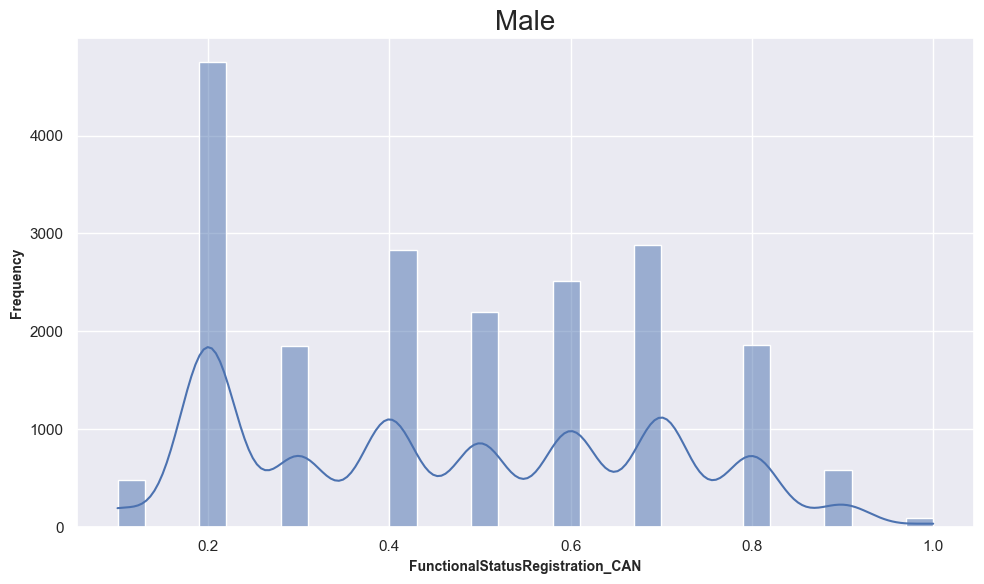

In [82]:
plot_histogram(df_m, 'FunctionalStatusRegistration_CAN', bins=30, txt='Male')

In [83]:
u.check_informative_missingness(df_m, 'FunctionalStatusRegistration_CAN', txt='Male')

--- Missingness (Male): FunctionalStatusRegistration_CAN ---
Group Sizes:    (Unknown=690, Known=20,047)
Mean survival:  (Unknown=1,136.8d, Known=1,336.1d)
Difference:     -199.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1878 (Negligible)
95% CI:        [-0.2637, -0.1119]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [84]:
u.continuous_value_predicts_survival(df_m, 'FunctionalStatusRegistration_CAN', txt='Male')

--- Value Predicts Survival (Male): FunctionalStatusRegistration_CAN ---
Pearson r=0.117, p=1.691e-62 & Approx. Variance Explained=1.379%
Spearman r=0.117, p=2.316e-62 & Approx. Variance Explained=1.376%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [85]:
# impute: median and use new feature for NANS
df_m['FunctionalStatusRegistration_Ismissing'] = df_m ['FunctionalStatusRegistration_CAN'].isna().astype(int)
df_m['FunctionalStatusRegistration_CAN'] = df_m['FunctionalStatusRegistration_CAN'].fillna(
    df_m['FunctionalStatusRegistration_CAN'].median()
)
# sanity check
df_m.FunctionalStatusRegistration_Ismissing.sum()

np.int64(690)

#### Female

In [86]:
# info
features = u.get_feature_info(df_f, 'FunctionalStatusRegistration', cat=False)

                                   count      mean       std  min  25%  50%  75%  max
FunctionalStatusRegistration_CAN  7327.0  0.471011  0.219268  0.1  0.2  0.5  0.7  1.0

:::: NaN Count:
FunctionalStatusRegistration_CAN    262 



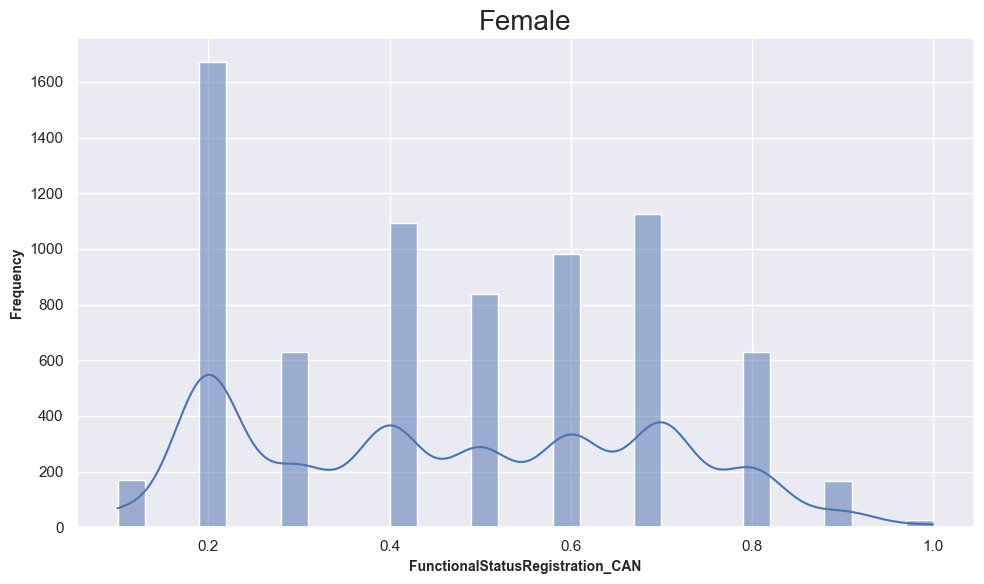

In [87]:
plot_histogram(df_f, 'FunctionalStatusRegistration_CAN', bins=30, txt='Female')

In [88]:
u.check_informative_missingness(df_f, 'FunctionalStatusRegistration_CAN', txt='Female')

--- Missingness (Female): FunctionalStatusRegistration_CAN ---
Group Sizes:    (Unknown=262, Known=7,327)
Mean survival:  (Unknown=1,172.5d, Known=1,337.5d)
Difference:     -165.0 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0120
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1544 (Negligible)
95% CI:        [-0.2777, -0.0312]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [89]:
u.continuous_value_predicts_survival(df_f, 'FunctionalStatusRegistration_CAN', txt='Female')

--- Value Predicts Survival (Female): FunctionalStatusRegistration_CAN ---
Pearson r=0.122, p=7.166e-26 & Approx. Variance Explained=1.499%
Spearman r=0.123, p=4.139e-26 & Approx. Variance Explained=1.514%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [90]:
# impute: median and use new feature for NANS
df_f['FunctionalStatusRegistration_Ismissing'] = df_f['FunctionalStatusRegistration_CAN'].isna().astype(int)
df_f['FunctionalStatusRegistration_CAN'] = df_f['FunctionalStatusRegistration_CAN'].fillna(
    df_f['FunctionalStatusRegistration_CAN'].median()
)

## Functional Status Transplant

#### Male

In [91]:
# info
features = u.get_feature_info(df_m, 'FunctionalStatusTransplant', cat=False)

                                  count     mean       std  min  25%  50%  75%  max
FunctionalStatusTransplant_CAN  19773.0  0.43432  0.238572  0.1  0.2  0.4  0.6  1.0

:::: NaN Count:
FunctionalStatusTransplant_CAN    964 



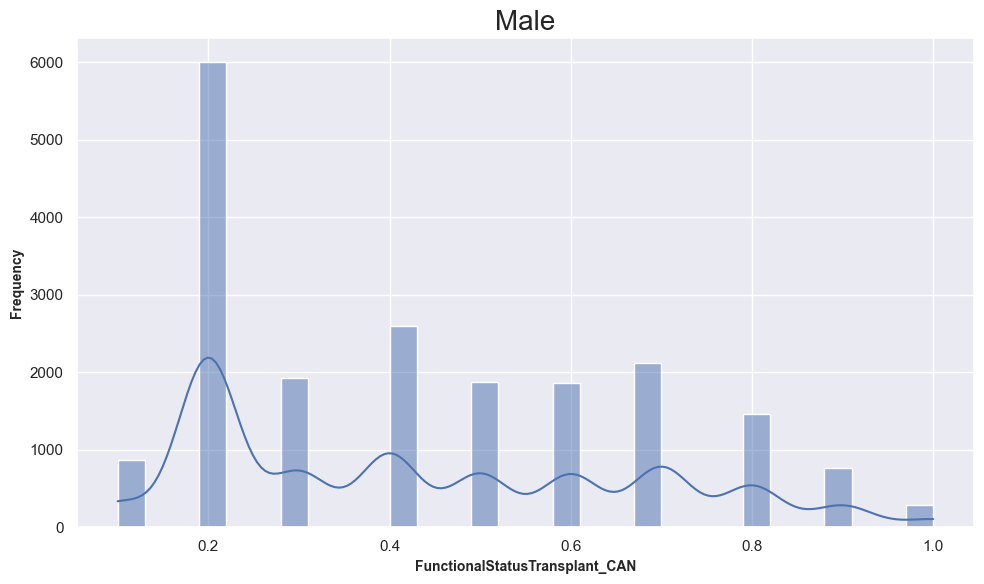

In [92]:
plot_histogram(df_m, 'FunctionalStatusTransplant_CAN', bins=30, txt='Male')

In [93]:
u.check_informative_missingness(df_m, 'FunctionalStatusTransplant_CAN', txt='Male')

--- Missingness (Male): FunctionalStatusTransplant_CAN ---
Group Sizes:    (Unknown=964, Known=19,773)
Mean survival:  (Unknown=1,095.9d, Known=1,340.9d)
Difference:     -245.0 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2309 (Small)
95% CI:        [-0.2956, -0.1662]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [94]:
u.continuous_value_predicts_survival(df_m, 'FunctionalStatusTransplant_CAN', txt='Male')

--- Value Predicts Survival (Male): FunctionalStatusTransplant_CAN ---
Pearson r=0.189, p=1.166e-158 & Approx. Variance Explained=3.578%
Spearman r=0.189, p=8.058e-159 & Approx. Variance Explained=3.581%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [95]:
# impute: median and use new feature for NANS
df_m['FunctionalStatusTransplant_Ismissing'] = df_m['FunctionalStatusTransplant_CAN'].isna().astype(int)
df_m['FunctionalStatusTransplant_CAN'] = df_m['FunctionalStatusTransplant_CAN'].fillna(
    df_m['FunctionalStatusTransplant_CAN'].median()
)

In [96]:
df_m[['FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN']].corr()

,FunctionalStatusRegistration_CAN,FunctionalStatusTransplant_CAN
FunctionalStatusRegistration_CAN,1.000000,0.480418
FunctionalStatusTransplant_CAN,0.480418,1.000000


#### Female

In [97]:
# info
features = u.get_feature_info(df_f, 'FunctionalStatusTransplant', cat=False)

                                 count      mean       std  min  25%  50%  75%  max
FunctionalStatusTransplant_CAN  7201.0  0.430912  0.230615  0.1  0.2  0.4  0.6  1.0

:::: NaN Count:
FunctionalStatusTransplant_CAN    388 



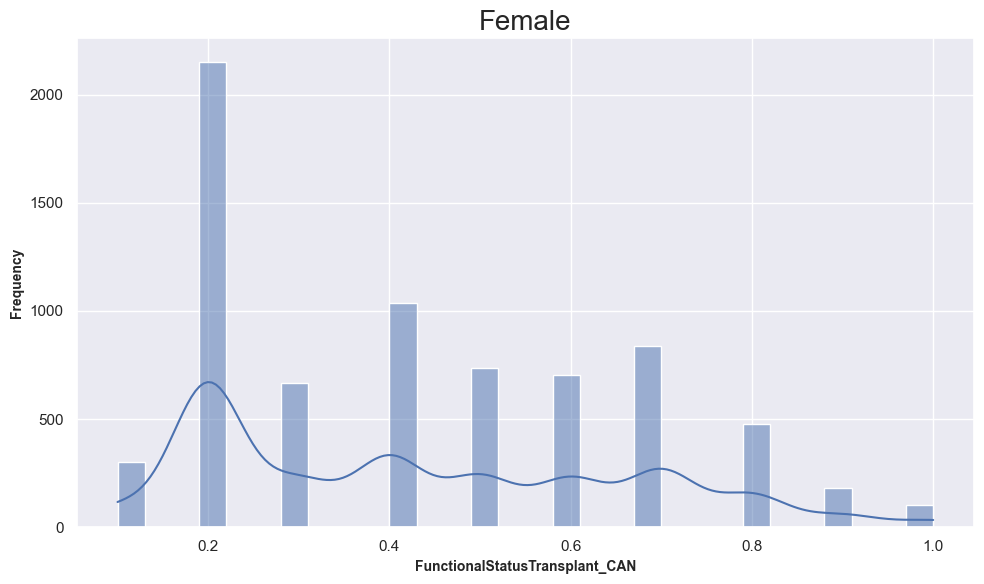

In [98]:
plot_histogram(df_f, 'FunctionalStatusTransplant_CAN', bins=30, txt='Female')

In [99]:
u.check_informative_missingness(df_f, 'FunctionalStatusTransplant_CAN', txt='Female')

--- Missingness (Female): FunctionalStatusTransplant_CAN ---
Group Sizes:    (Unknown=388, Known=7,201)
Mean survival:  (Unknown=1,120.5d, Known=1,343.2d)
Difference:     -222.6 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2085 (Small)
95% CI:        [-0.3107, -0.1063]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [100]:
u.continuous_value_predicts_survival(df_f, 'FunctionalStatusTransplant_CAN', txt='Female')

--- Value Predicts Survival (Female): FunctionalStatusTransplant_CAN ---
Pearson r=0.161, p=8.454e-43 & Approx. Variance Explained=2.579%
Spearman r=0.150, p=1.029e-37 & Approx. Variance Explained=2.263%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [101]:
# impute: median and use new feature for NANS
df_f['FunctionalStatusTransplant_Ismissing'] = df_f['FunctionalStatusTransplant_CAN'].isna().astype(int)
df_f['FunctionalStatusTransplant_CAN'] = df_f['FunctionalStatusTransplant_CAN'].fillna(
    df_f['FunctionalStatusTransplant_CAN'].median()
)

In [102]:
df_f[['FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN']].corr()

,FunctionalStatusRegistration_CAN,FunctionalStatusTransplant_CAN
FunctionalStatusRegistration_CAN,1.000000,0.508993
FunctionalStatusTransplant_CAN,0.508993,1.000000


## Creatinine Registration
#### [Creatinine](https://johnshopkinshealthcare.staywellsolutionsonline.com/BreatheEasy/167,creatinine_serum)
* Creatinine is a waste product that forms when creatine, a substance found in your muscles, breaks down. It's usually filtered out of the blood by the kidneys and excreted in urine. Measuring creatinine levels in the blood can help assess kidney function.
    * Normal
        * 0.7 to 1.3 mg/dL for adult males
        * 0.5 to 1.1 mg/dL for adult females
* High creatinine indicates elevated levels of a waste product in the blood, primarily signaling that the kidneys are not filtering efficiently, commonly termed renal dysfunction, impaired kidney function, or kidney damage.

#### Male

In [103]:
# info
features = u.get_feature_info(df_m, 'CreatinineRegistration_CAN', cat=False)

                              count      mean       std   min  25%   50%   75%   max
CreatinineRegistration_CAN  20660.0  1.425726  0.972279  0.08  1.0  1.22  1.54  24.0

:::: NaN Count:
CreatinineRegistration_CAN    77 



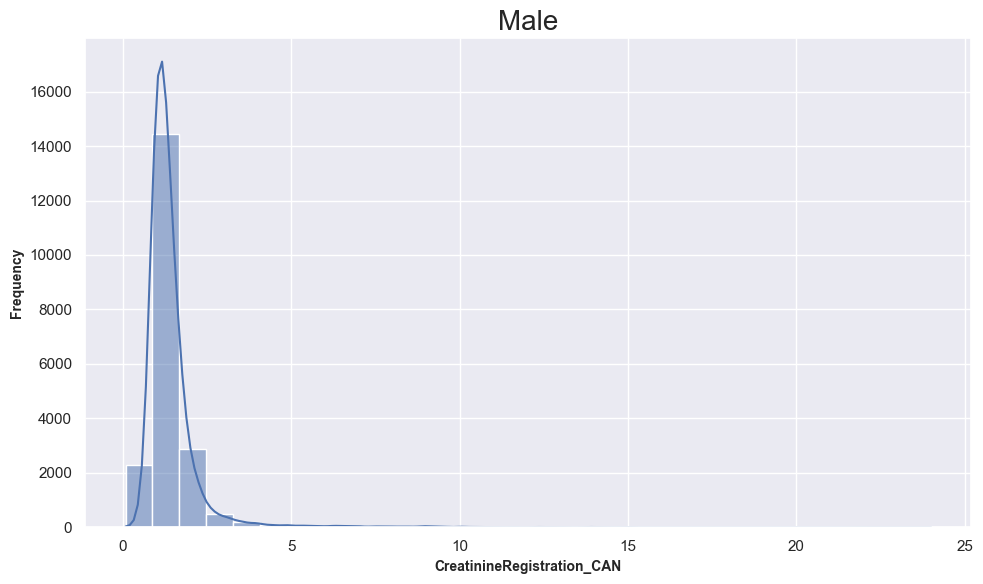

In [104]:
plot_histogram(df_m, 'CreatinineRegistration_CAN', bins=30, txt='Male')

In [105]:
u.check_informative_missingness(df_m, 'CreatinineRegistration_CAN', txt='Male')

--- Missingness (Male): CreatinineRegistration_CAN ---
Group Sizes:    (Unknown=77, Known=20,660)
Mean survival:  (Unknown=1,032.2d, Known=1,330.6d)
Difference:     -298.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0186
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2810 (Small)
95% CI:        [-0.5048, -0.0572]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [106]:
u.continuous_value_predicts_survival(df_m, 'CreatinineRegistration_CAN', txt='Male')

--- Value Predicts Survival (Male): CreatinineRegistration_CAN ---
Pearson r=-0.048, p=3.929e-12 & Approx. Variance Explained=0.233%
Spearman r=-0.060, p=4.147e-18 & Approx. Variance Explained=0.364%



#### Female

In [107]:
features = u.get_feature_info(df_f, 'CreatinineRegistration_CAN', cat=False)

                             count      mean      std   min  25%  50%  75%   max
CreatinineRegistration_CAN  7571.0  1.188488  0.89835  0.19  0.8  1.0  1.3  21.0

:::: NaN Count:
CreatinineRegistration_CAN    18 



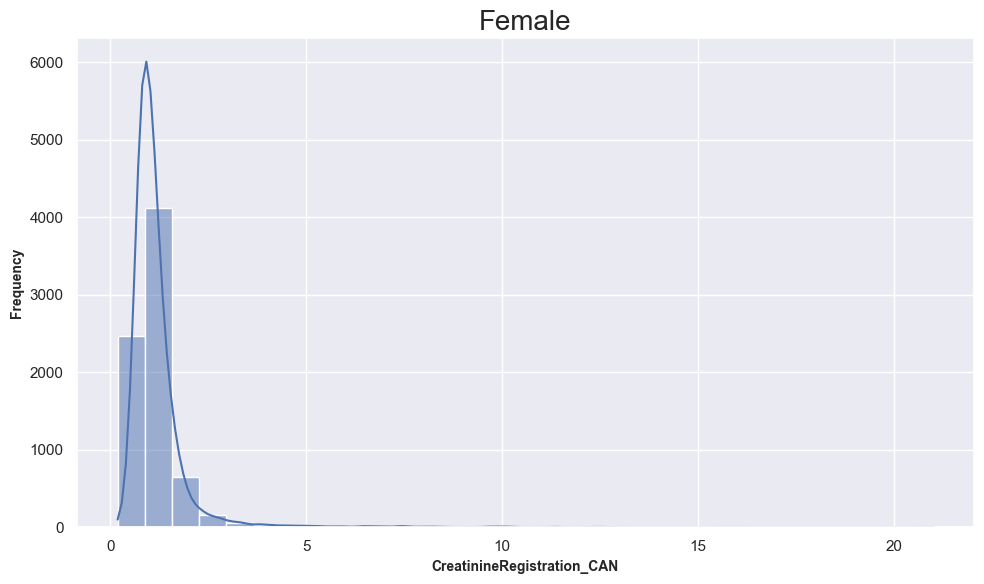

In [108]:
plot_histogram(df_f, 'CreatinineRegistration_CAN', bins=30, txt='Female')

In [109]:
u.check_informative_missingness(df_f, 'CreatinineRegistration_CAN', txt='Female')

--- Missingness (Female): CreatinineRegistration_CAN ---
Group Sizes:    (Unknown=18, Known=7,571)
Mean survival:  (Unknown=1,526.8d, Known=1,331.3d)
Difference:     195.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.4925
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.1829 (Negligible)
95% CI:        [-0.2796, 0.6454]
Result: Likely Random Missingness (Effect size not significant)



In [110]:
u.continuous_value_predicts_survival(df_f, 'CreatinineRegistration_CAN', txt='Female')

--- Value Predicts Survival (Female): CreatinineRegistration_CAN ---
Pearson r=-0.048, p=2.955e-05 & Approx. Variance Explained=0.230%
Spearman r=-0.041, p=0.0003371 & Approx. Variance Explained=0.170%



#### Log Transform

In [111]:
# Log Transform
df_m['CreatinineRegistration_Log'] = np.log1p(df_m.CreatinineRegistration_CAN)
# female
df_f['CreatinineRegistration_Log'] = np.log1p(df_f.CreatinineRegistration_CAN)
# remove
df_m = df_m.drop('CreatinineRegistration_CAN', axis=1)
df_f = df_f.drop('CreatinineRegistration_CAN', axis=1)

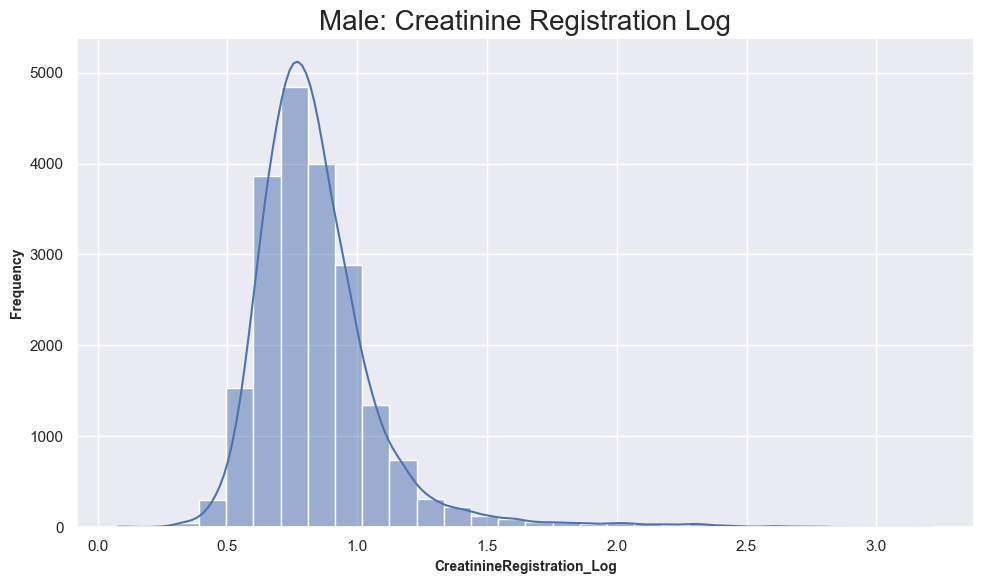

In [112]:
plot_histogram(df_m, 'CreatinineRegistration_Log', txt='Male: Creatinine Registration Log', bins=30)

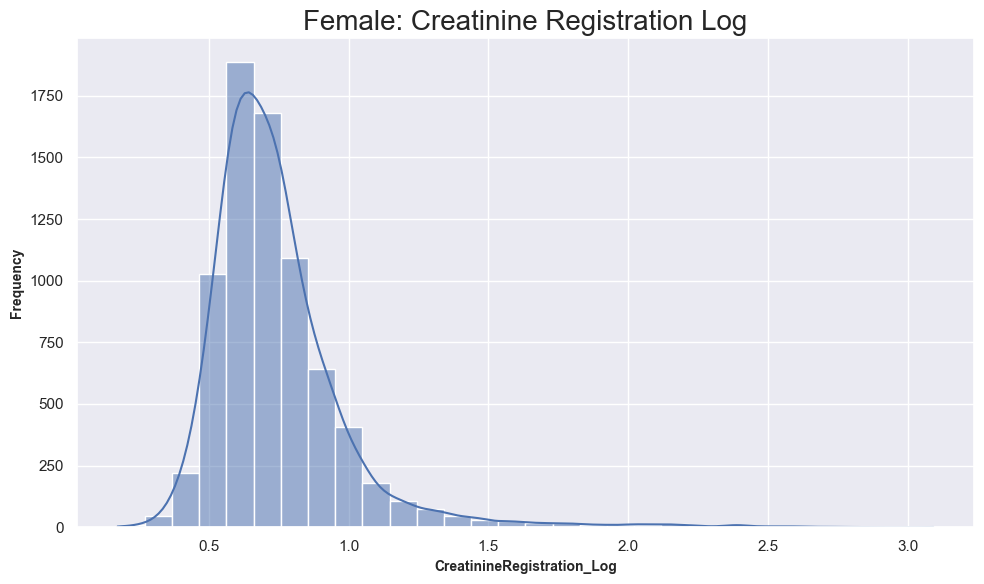

In [113]:
plot_histogram(df_f, 'CreatinineRegistration_Log', txt='Female: Creatinine Registration Log', bins=30)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [114]:
# impute: median and use new feature for NANS
df_m['CreatinineRegistration_Log_Ismissing'] = df_m.CreatinineRegistration_Log.isna().astype(int)
# female
df_f['CreatinineRegistration_Log_Ismissing'] = df_f.CreatinineRegistration_Log.isna().astype(int)
# median
df_m['CreatinineRegistration_Log'] = df_m.CreatinineRegistration_Log.fillna(df_m.CreatinineRegistration_Log.median())
# female
df_f['CreatinineRegistration_Log'] = df_f.CreatinineRegistration_Log.fillna(df_f.CreatinineRegistration_Log.median())
# sanity check
df_m['CreatinineRegistration_Log_Ismissing'].sum(), df_f['CreatinineRegistration_Log_Ismissing'].sum()

(np.int64(77), np.int64(18))

## Creatinine Transplant

#### Male

In [115]:
# info
features = u.get_feature_info(df_m, 'CreatinineTransplant_CAN', cat=False)

                            count      mean       std   min  25%   50%   75%   max
CreatinineTransplant_CAN  20696.0  1.435522  0.998759  0.06  1.0  1.24  1.57  37.0

:::: NaN Count:
CreatinineTransplant_CAN    41 



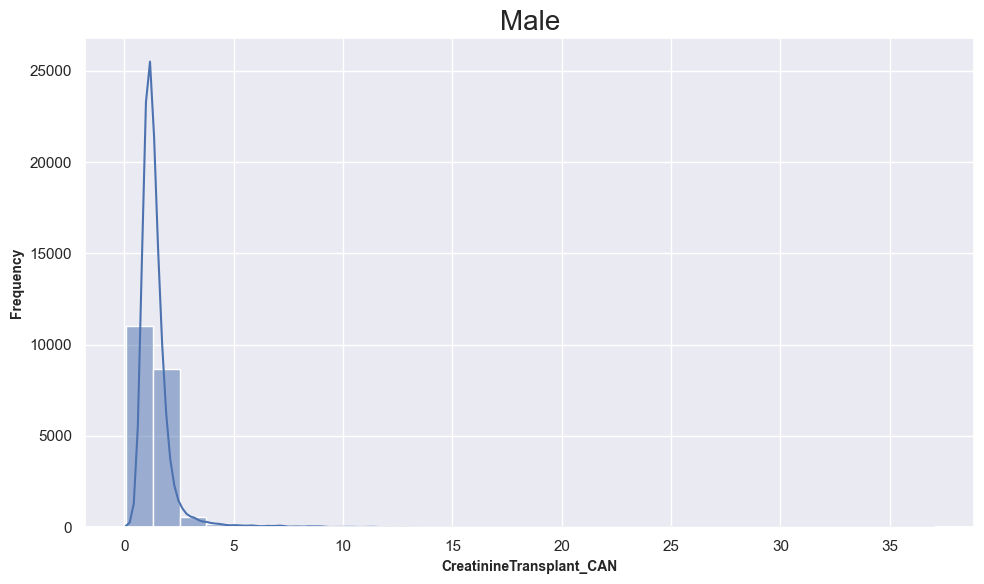

In [116]:
plot_histogram(df_m, 'CreatinineTransplant_CAN', bins=30, txt='Male')

In [117]:
u.check_informative_missingness(df_m, 'CreatinineTransplant_CAN', txt='Male')

--- Missingness (Male): CreatinineTransplant_CAN ---
Group Sizes:    (Unknown=41, Known=20,696)
Mean survival:  (Unknown=174.6d, Known=1,331.8d)
Difference:     -1,157.2 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -1.0909 (Large)
95% CI:        [-1.3975, -0.7843]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [118]:
u.continuous_value_predicts_survival(df_m, 'CreatinineTransplant_CAN', txt='Female')

--- Value Predicts Survival (Female): CreatinineTransplant_CAN ---
Pearson r=-0.032, p=4.712e-06 & Approx. Variance Explained=0.101%
Spearman r=-0.033, p=1.889e-06 & Approx. Variance Explained=0.110%



#### Female

In [119]:
# info
features = u.get_feature_info(df_f, 'CreatinineTransplant_CAN', cat=False)

                           count      mean       std   min  25%  50%  75%   max
CreatinineTransplant_CAN  7575.0  1.199665  0.993362  0.13  0.8  1.0  1.3  24.0

:::: NaN Count:
CreatinineTransplant_CAN    14 



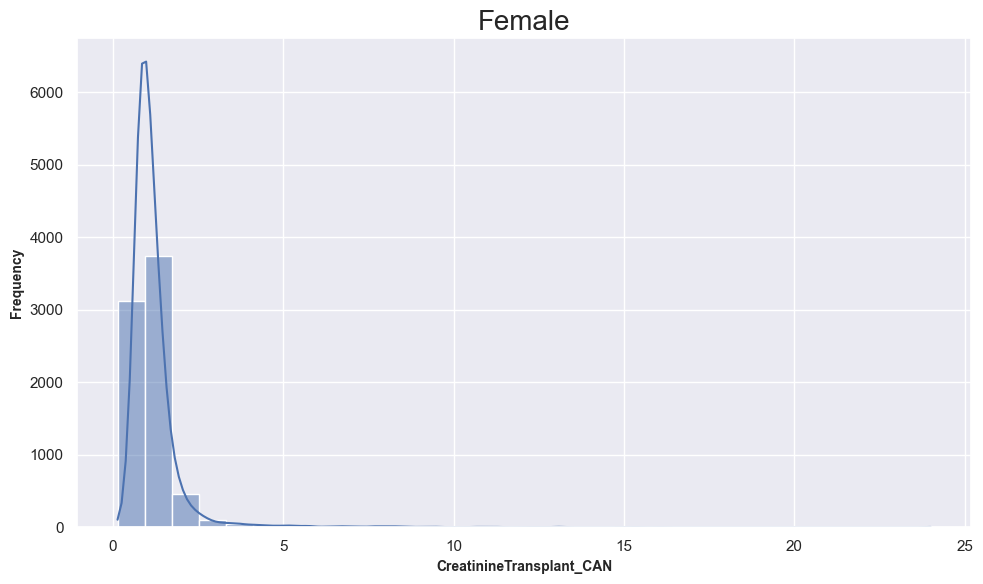

In [120]:
plot_histogram(df_f, 'CreatinineTransplant_CAN', bins=30, txt='Female')

In [121]:
u.check_informative_missingness(df_f, 'CreatinineTransplant_CAN', txt='Female')

--- Missingness (Female): CreatinineTransplant_CAN ---
Group Sizes:    (Unknown=14, Known=7,575)
Mean survival:  (Unknown=303.6d, Known=1,333.7d)
Difference:     -1,030.1 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.9645 (Large)
95% CI:        [-1.4890, -0.4399]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [122]:
u.continuous_value_predicts_survival(df_f, 'CreatinineTransplant_CAN', txt='Female')

--- Value Predicts Survival (Female): CreatinineTransplant_CAN ---
Pearson r=-0.049, p=2.27e-05 & Approx. Variance Explained=0.237%
Spearman r=-0.032, p=0.004685 & Approx. Variance Explained=0.106%



#### Log Transform

In [123]:
# Log Transform
df_m['CreatinineTransplant_Log'] = np.log1p(df_m.CreatinineTransplant_CAN)
# female
df_f['CreatinineTransplant_Log'] = np.log1p(df_f.CreatinineTransplant_CAN)
# remove
df_m = df_m.drop('CreatinineTransplant_CAN', axis=1)
df_f = df_f.drop('CreatinineTransplant_CAN', axis=1)

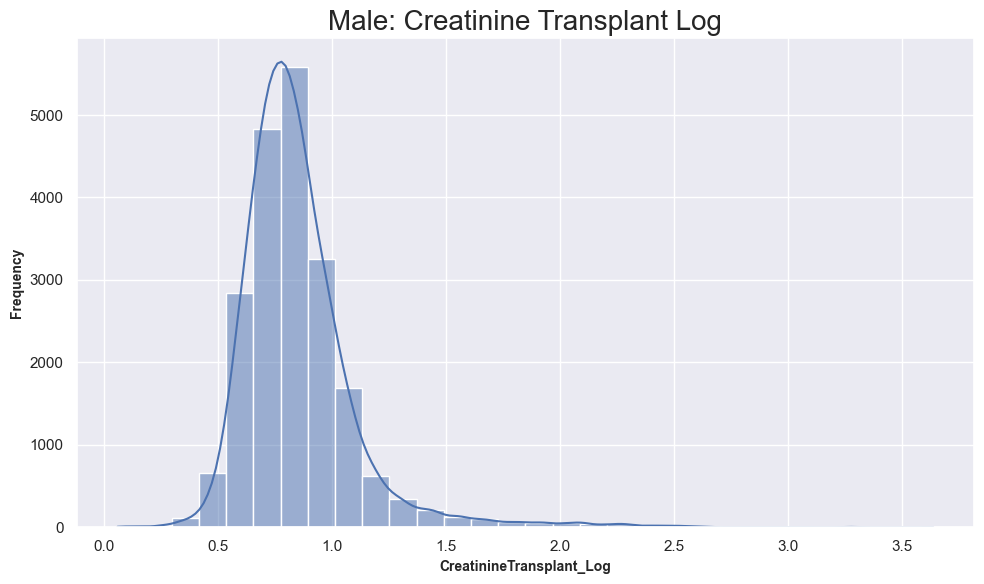

In [124]:
plot_histogram(df_m, 'CreatinineTransplant_Log', txt='Male: Creatinine Transplant Log', bins=30)

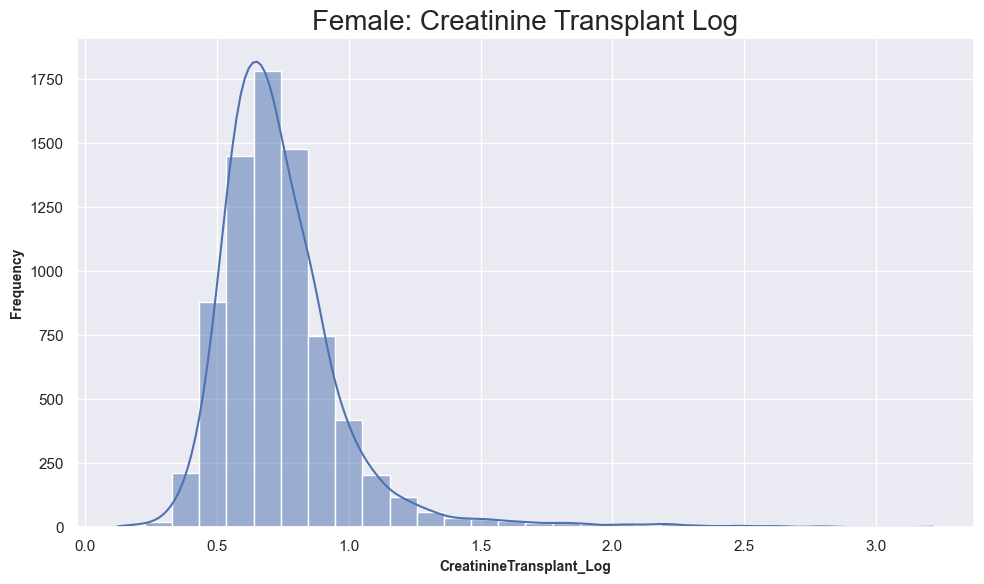

In [125]:
plot_histogram(df_f, 'CreatinineTransplant_Log', txt='Female: Creatinine Transplant Log', bins=30)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [126]:
# impute: median and use new feature for NANS
df_m['CreatinineTransplant_Log_Ismissing'] = df_m.CreatinineTransplant_Log.isna().astype(int)
# female
df_f['CreatinineTransplant_Log_Ismissing'] = df_f.CreatinineTransplant_Log.isna().astype(int)
# median
df_m['CreatinineTransplant_Log'] = df_m.CreatinineTransplant_Log.fillna(df_m.CreatinineTransplant_Log.median())
# female
df_f['CreatinineTransplant_Log'] = df_f.CreatinineTransplant_Log.fillna(df_f.CreatinineTransplant_Log.median())
# sanity check
df_m['CreatinineTransplant_Log_Ismissing'].sum(), df_f['CreatinineTransplant_Log_Ismissing'].sum()

(np.int64(41), np.int64(14))

## TotalBilirubin Transplant
* Bilirubin levels can be an important factor in heart transplantation, particularly in the context of post-operative outcomes. Elevated bilirubin levels, or hyperbilirubinemia, can indicate liver dysfunction, which is a common complication following cardiac surgery, including heart transplantation.
    * Prognostic Marker: Hyperbilirubinemia is often used as a prognostic marker for adverse outcomes after cardiac surgery. Elevated bilirubin levels are associated with increased in-hospital mortality, prolonged ICU stays, and other complications.
    * Incidence and Risk Factors: The incidence of hyperbilirubinemia after cardiac surgery varies widely, with reports ranging from 8.6% to 40%. Risk factors include the type of surgery, duration of cardiopulmonary bypass, and pre-existing liver conditions.
    * Management: Managing elevated bilirubin levels involves addressing the underlying causes, such as improving liver perfusion and reducing hemolysis. Treatments like bilirubin adsorption and plasma exchange have been studied for their efficacy in reducing bilirubin levels and improving outcomes.
    * Impact on Transplant Outcomes: High bilirubin levels can complicate the post-operative course and affect the overall success of the heart transplant. Monitoring and managing bilirubin levels is crucial for improving patient outcomes.

**Note:** Men generally have higher serum bilirubin levels than women, with average levels around in men compared to in women, a trend that holds across various age groups. This difference is likely driven by higher red blood cell counts in men and potential effects of sex hormones, such as progesterone and estradiol (key female sex hormones produced by the ovaries that regulate the menstrual cycle, pregnancy, and menopause).

#### Male

In [127]:
# info
features = u.get_feature_info(df_m, 'TotalBilirubinTransplant', cat=False) 

                                count      mean       std  min  25%  50%  75%   max
TotalBilirubinTransplant_CAN  20672.0  1.029362  1.722646  0.1  0.5  0.7  1.1  61.0

:::: NaN Count:
TotalBilirubinTransplant_CAN    65 



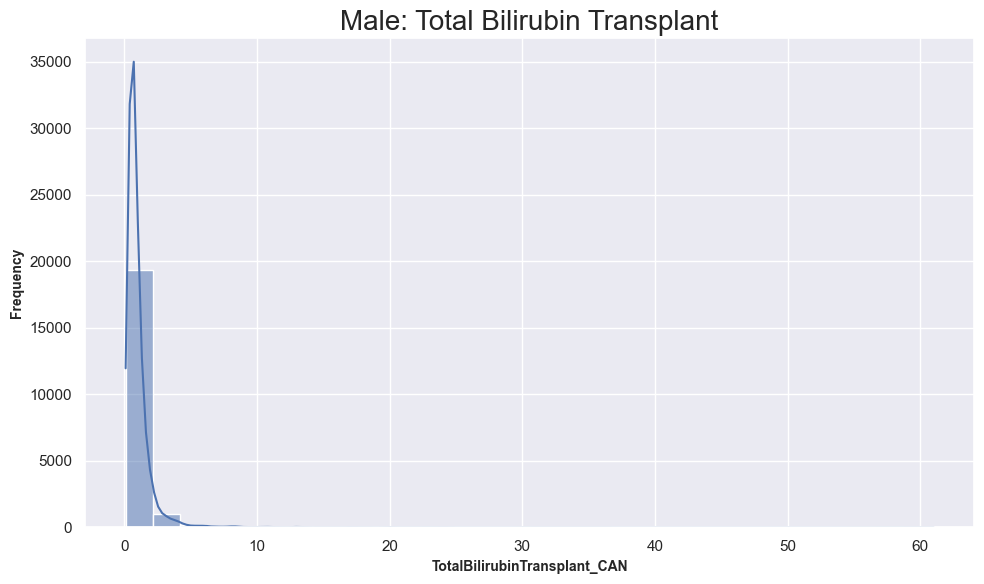

In [128]:
plot_histogram(df_m, 'TotalBilirubinTransplant_CAN', txt='Male: Total Bilirubin Transplant', bins=30)

In [129]:
u.check_informative_missingness(df_m, 'TotalBilirubinTransplant_CAN', txt='Male')

--- Missingness (Male): TotalBilirubinTransplant_CAN ---
Group Sizes:    (Unknown=65, Known=20,672)
Mean survival:  (Unknown=707.3d, Known=1,331.5d)
Difference:     -624.2 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.5880 (Medium)
95% CI:        [-0.8316, -0.3445]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [130]:
u.continuous_value_predicts_survival(df_m, 'TotalBilirubinTransplant_CAN', txt='Male')

--- Value Predicts Survival (Male): TotalBilirubinTransplant_CAN ---
Pearson r=-0.041, p=4.664e-09 & Approx. Variance Explained=0.166%
Spearman r=-0.007, p=0.3175 & Approx. Variance Explained=0.005%



#### Female

In [131]:
# info
features = u.get_feature_info(df_f, 'TotalBilirubinTransplant', cat=False) 

                               count      mean      std  min  25%  50%  75%   max
TotalBilirubinTransplant_CAN  7558.0  0.894024  1.68745  0.1  0.4  0.6  1.0  80.0

:::: NaN Count:
TotalBilirubinTransplant_CAN    31 



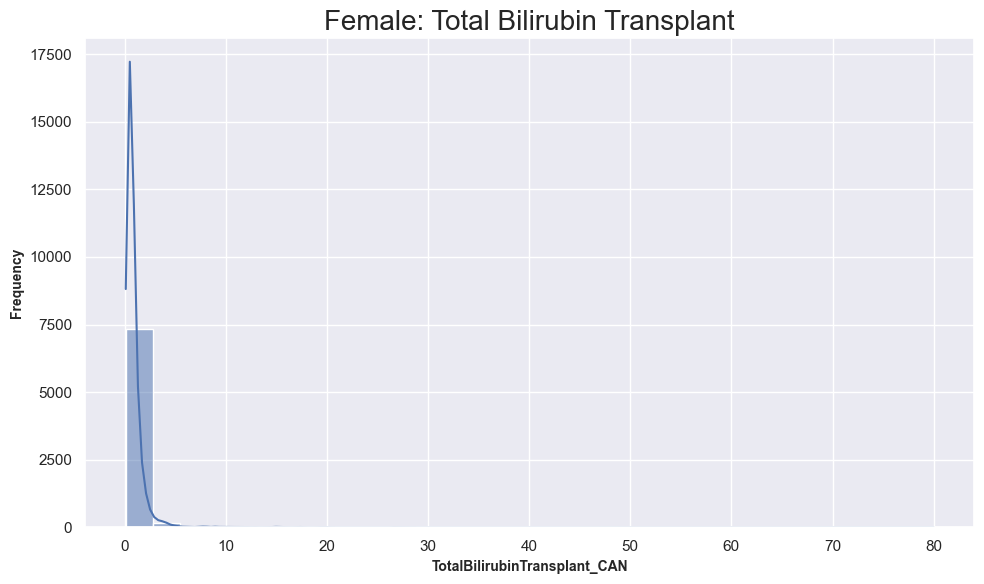

In [132]:
plot_histogram(df_f, 'TotalBilirubinTransplant_CAN', txt='Female: Total Bilirubin Transplant', bins=30)

In [133]:
u.check_informative_missingness(df_f, 'TotalBilirubinTransplant_CAN', txt='Female')

--- Missingness (Female): TotalBilirubinTransplant_CAN ---
Group Sizes:    (Unknown=31, Known=7,558)
Mean survival:  (Unknown=1,271.9d, Known=1,332.0d)
Difference:     -60.1 days

--- Welch's t-test Analysis ---
ρ-Value: 0.8025
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0563 (Negligible)
95% CI:        [-0.4090, 0.2965]
Result: Likely Random Missingness (Effect size not significant)



In [134]:
u.continuous_value_predicts_survival(df_f, 'TotalBilirubinTransplant_CAN', txt='Female')

--- Value Predicts Survival (Female): TotalBilirubinTransplant_CAN ---
Pearson r=-0.025, p=0.03286 & Approx. Variance Explained=0.060%
Spearman r=0.002, p=0.8539 & Approx. Variance Explained=0.000%



#### Log Transform

In [135]:
# Log Transform
df_m['TotalBilirubinTransplant_Log'] = np.log1p(df_m.TotalBilirubinTransplant_CAN)
# female
df_f['TotalBilirubinTransplant_Log'] = np.log1p(df_f.TotalBilirubinTransplant_CAN)
# remove
df_m = df_m.drop('TotalBilirubinTransplant_CAN', axis=1)
df_f = df_f.drop('TotalBilirubinTransplant_CAN', axis=1)

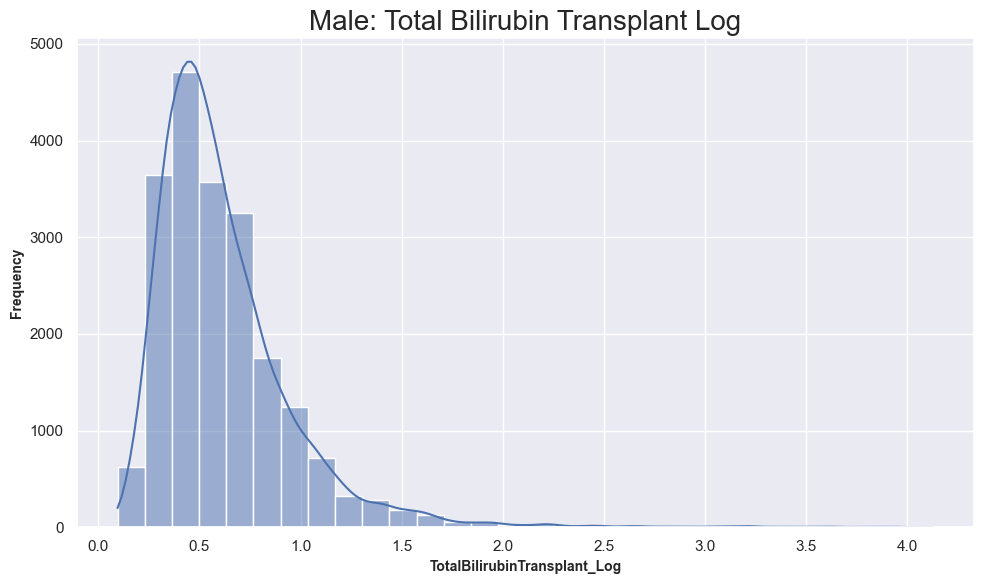

In [136]:
plot_histogram(df_m, 'TotalBilirubinTransplant_Log', txt='Male: Total Bilirubin Transplant Log', bins=30)

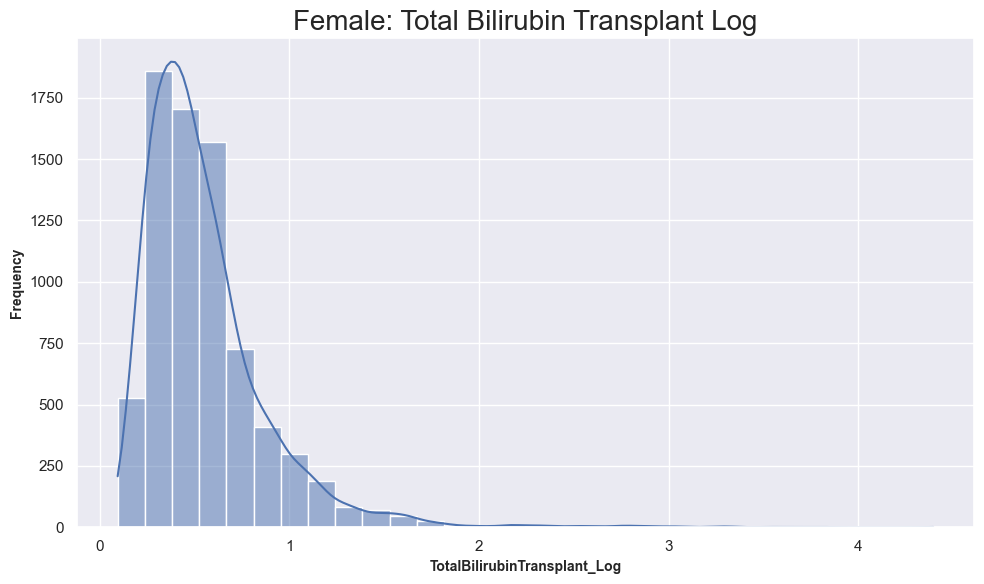

In [137]:
plot_histogram(df_f, 'TotalBilirubinTransplant_Log', txt='Female: Total Bilirubin Transplant Log', bins=30)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [138]:
# impute: median and use new feature for NANS
df_m['TotalBilirubinTransplant_Log_Ismissing'] = df_m.TotalBilirubinTransplant_Log.isna().astype(int)
# female
df_f['TotalBilirubinTransplant_Log_Ismissing'] = df_f.TotalBilirubinTransplant_Log.isna().astype(int)
# median
df_m['TotalBilirubinTransplant_Log'] = df_m.TotalBilirubinTransplant_Log.fillna(df_m.TotalBilirubinTransplant_Log.median())
# female
df_f['TotalBilirubinTransplant_Log'] = df_f.TotalBilirubinTransplant_Log.fillna(df_f.TotalBilirubinTransplant_Log.median())
# sanity check
df_m['TotalBilirubinTransplant_Log_Ismissing'].sum(), df_f['TotalBilirubinTransplant_Log_Ismissing'].sum()

(np.int64(65), np.int64(31))

## Weight (Kg)

In [139]:
# info
features = u.get_feature_info(df_m, 'WeightKg_CAN', cat=False) 

                count       mean        std   min   25%   50%   75%    max
WeightKg_CAN  20735.0  87.661452  16.994804  29.9  75.3  86.6  99.3  165.1

:::: NaN Count:
WeightKg_CAN    2 



In [140]:
# info
features = u.get_feature_info(df_f, 'WeightKg_CAN', cat=False) 

               count       mean       std   min   25%   50%   75%    max
WeightKg_CAN  7584.0  71.629022  15.70975  32.5  59.7  70.3  82.6  143.3

:::: NaN Count:
WeightKg_CAN    5 



In [141]:
# impute: median
df_m['WeightKg_CAN'] = df_m.WeightKg_CAN.fillna(df_m.WeightKg_CAN.median())
# female
df_f['WeightKg_CAN'] = df_f.WeightKg_CAN.fillna(df_f.WeightKg_CAN.median())

In [142]:
# check NaNs
df_m.WeightKg_CAN.isna().any().any(), df_f.WeightKg_CAN.isna().any().any()

(np.False_, np.False_)

#### Write to Disk: Candidate Data

In [143]:
# save data: heart dataset
u.write_to_file(df_f, 'Candidate_Female_Heart',path='../Data/', format='pkl')
u.write_to_file(df_m, 'Candidate_Male_Heart',path='../Data/', format='pkl')

7,589 records written to ../Data/Candidate_Female_Heart.pkl
20,737 records written to ../Data/Candidate_Male_Heart.pkl
